# Volt-VAr-Induced Curtailment Detection

Find instances where active-power curtailment is happening *because* the inverter is absorbing
reactive power (Volt-VAr response) and has run out of apparent-power headroom.

## The physics logic

An inverter rated `S_rated` kVA can deliver any combination of active power `P` and reactive
power `Q` as long as they stay inside the **apparent-power circle**: `sqrt(P² + Q²) ≤ S_rated`.

When grid voltage is high (e.g. 240 to 258 V), AS/NZS 4777.2 requires the inverter to **absorb**
reactive power. That absorption consumes part of the apparent-power "budget", so
if the irradiance is strong enough that the inverter *wants* to push out a lot of `P`, it may be
**forced to reduce `P`** to make room for the required `Q`. That reduction is labelled **Volt-VAr-induced curtailment**, distinct from Volt-Watt curtailment (which only kicks in above 253 V).

## Conditions to find Volt-VAr-induced curtailment timestamps

| # | Condition | Reason |
|---|-----------|-----|
| 1 | Clear-sky day (GHI) | so we know the inverter *could* have produced near its max |
| 2 | Peak solar window (≈11:00 to 13:00)* | when `P` is naturally highest. Most likely to hit the limit (*might be irrelevant) |
| 3 | `240 < V < 253` | V-VAr absorbing is **active** (Australia A), but V-Watt is **not yet**. Isolates the Volt-VAr effect |
| → | `sqrt(P² + Q²) ≳ S_rated` | inverter is riding its apparent-power limit |

## Two complementary tests

| Method | Uses | Answers |
|--------|------|---------|
| **A: Symptom detection** | measured P, Q, V from `ts` | *Which sites/intervals show the inverter riding its apparent-power limit while absorbing VAr?* |
| **B: Counterfactual quantification** | `all_uncurtailedpv` (GHI model) | *How many kWh of P were actually lost to VAr?* |


###  Some notes
1. **Use `S_99`, not nameplate, for the limit**: the CICCADA data pipeline normalises by `S_99`
   (99th-percentile observed apparent power), because the *effective* inverter limit in the data
   is often below the nameplate. Using nameplate could under-count curtailment.(nameplate is also pulled)
2. **Reactive sign convention.** Everything here assumes **−Q = absorbing**. If the fleet's raw
   `energy_reactive` sign is flipped, the whole detection inverts. There's a sanity-check cell.
3. **"Clear sky" needs a definition.** GHI being *high* isn't enough. It must be *stable*
   (not punching through cloud gaps). We use `GHI / GHI_clear_sky` near 1.0 **and** low local
   variance. The `structured_data` table already has `ghi` and `ghi_cs` so we use their ratio.
4. **Peak-solar window is in local time.** `t_stamp` is UTC. Convert to AEST (UTC+10) first,
   or the 11:00 to 13:00 window lands in the wrong place.
5. **Three-phase sites.** Aggregate P and Q across **all** PV circuits before computing S, and use
   `max(voltage)` across circuits (the worst phase is what triggers the VAr response).


## Notes before running

### 1. Where do `ghi` and `ghi_cs` come from, and how are they calculated?

Both live in **`structured_data`**, the table the GHI/curtailment pipeline is built from
(`ghi_pv_estimator_general/Write_structured_data.ipynb`). Neither is a raw satellite produc. Both are derived:

- **`ghi`**: Bureau of Meteorology / NCI satellite irradiance, natively **10-minute** resolution,
  matched to each site's nearest lat/long grid cell. It is resampled to 5-minute by **duplicating**
  each 10-min reading and shifting the copy +5 minutes (not interpolated). So odd 5-minute
  intervals carry the *same* GHI value as the preceding even one. This means the practical
  temporal resolution of `ghi` is still 10 minutes, not 5.

- **`ghi_cs`** ("clear-sky GHI"): *not* a physical clear-sky model (e.g. Ineichen). It's
  **empirical**: for each site, the pipeline finds the **clearest day per month** at that
  location (lowest summed cloud-type index, `cloud_sum < 60`, peak GHI `> 200`), then for any
  given day it finds the **nearest such clear-sky day** (by calendar distance, ≤45 days). Within
  that reference day, `ghi_cs` at each 5-minute time-of-day bin is the **60th percentile of GHI**
  over a ±3-interval rolling window (`approx_percentile(GHI, 0.6) OVER (... ROWS BETWEEN 3
  PRECEDING AND 3 FOLLOWING)`), computed within continuous data segments (a gap >30 min starts a
  new segment). 
  The same logic builds `P_kw_norm_cs`, the matching clear-sky **power** shape.

So `ghi/ghi_cs` is "how much sun today, relative to the clearest day this site saw nearby in the
calendar". Not an absolute clear-sky physics model. 

This matters for you: a "clear-sky" flag near `ghi/ghi_cs ≈ 1` only means *as clear as the best recent reference day*, which might be an imperfect proxy in persistently overcast regions.


### 2. On three phase inverters

For three-phase sites, the inverter typically
responds to **per-phase** voltage, but our 240–253 V eligibility test uses `max(V)` — the worst
phase. A three-phase site could have one phase at 248 V (V-VAr-eligible) while the other two sit
at 235 V (not eligible), yet our aggregate `P` and `Q` are summed across all three. This is a
known simplification (shared with the rest of the pipeline) — it slightly overstates eligibility
for three-phase sites. If you want a cleaner read on this specific question, set
`PHASE_FILTER = "single"` to restrict to single-phase sites only, where this ambiguity doesn't
arise.


## Setup

In [1]:
from aws_config import *      # aq, dread, s3_ls, databases, tables, describe
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.patches import Patch

import seaborn as sns
import pytz

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid", font_scale=0.95)

In [2]:
SA  = "solar_analytics"
SAI = "solar_analytics_iceberg"
FIXED_OFFSET = pytz.FixedOffset(600)   # AEST = UTC+10, no DST

# AS/NZS 4777.2:2020 Australia-A Volt-VAr set-points
AS4777 = {
    "VVAR": {
        "V1": 207.0,
        "V2": 220.0,
        "V3": 240.0,
        "V4": 258.0,
        "Q1": 0.44,
        "Q4": 0.60
        },
    "VW":   {
        "V1": 253.0,
        "V2": 260.0,
        "P2": 0.20
        },
    "TOL_FRAC": 0.04,     # established 4% AC-capacity tolerance, used fleet-wide
    "INTERVAL_H": 5/60,
}


In [3]:
# Check whether structured_data has been extended to 2025
# year/month are columns in structured_data (likely partition columns, so this
# should be a relatively cheap aggregate, but it's still a full-table group-by).
ghi_year_check = aq("""
    SELECT year, count(*) AS n_rows, count(DISTINCT site_id) AS n_sites
    FROM structured_data
    GROUP BY year
    ORDER BY year
""", database=SAI)
print(ghi_year_check)

# If 2025 appears with a non-trivial row count, update:
# PARAMS["GHI_YEARS"] = [2024, 2025]

   year     n_rows  n_sites
0  2024  544084502    13967
1  2025  478816145    12737


In [4]:
# Detection parameters
PARAMS = {
    "YEARS":            [2024, 2025],  # years to scan in ts for Method A (multi-year supported)
    "GHI_YEARS":        [2024, 2025],  # years with structured_data / all_uncurtailedpv coverage
    "MAX_AC_CAPACITY_KW": 30.0,        # residential-scale systems only
    "V_LOW":            240.0,         # lower bound of V-VAr-only band
    "V_HIGH":           253.0,         # upper bound (V-Watt starts here)
    "PEAK_HOUR_START":  11,            # local (AEST) peak-solar window start
    "PEAK_HOUR_END":    13,            #   "          "            window end
    "GHI_CS_RATIO_MIN": 0.95,          # ghi/ghi_cs >= this assumes "clear enough"
                                       #   NOTE: not established elsewhere — tunable, see notes above
    "S_TOL_FRAC":       AS4777["TOL_FRAC"],  # "at the limit" tolerance, consistent with the
                                              #   4% convention used everywhere else (replaces
                                              #   the old, arbitrary S_LIMIT_FRAC=0.97)
    "USE_S99":          True,          # True: use S_99 as the apparent-power limit
                                       #   False: use ac_capacity_kw (nameplate)
    "PHASE_FILTER":     "all",         # "all" | "single" | "three"
                                       #   "all" matches the established 16,148-site cohort
                                       #   definition (1 inverter, up to 3 circuits)
}

print("Setup complete. Parameters:")
for k, v in PARAMS.items():
    print(f"  {k:18s} = {v}")


Setup complete. Parameters:
  YEARS              = [2024, 2025]
  GHI_YEARS          = [2024, 2025]
  MAX_AC_CAPACITY_KW = 30.0
  V_LOW              = 240.0
  V_HIGH             = 253.0
  PEAK_HOUR_START    = 11
  PEAK_HOUR_END      = 13
  GHI_CS_RATIO_MIN   = 0.95
  S_TOL_FRAC         = 0.04
  USE_S99            = True
  PHASE_FILTER       = all


## 1. Confirm the data

Data needed:
- **`ts`**: raw telemetry (P, Q, V).
- **`meta_up23c`**: `ac_capacity_kw`, `s_99`, circuit polarity, circuit count.
- **`structured_data`**: has `ghi` and `ghi_cs` (see explanation above). Confirmed 2024 only.

Run the check below. If `structured_data` is missing the `ghi` columns, we fall back to a
coarser clear-sky proxy (peak-hour window only, no irradiance check).

In [5]:
# Check structured_data schema for ghi columns
try:
    _sd = aq("SELECT * FROM structured_data LIMIT 1", database=SAI)
    print("structured_data columns:")
    print(list(_sd.columns))
    HAS_GHI = "ghi" in _sd.columns and "ghi_cs" in _sd.columns
    print(f"\nghi + ghi_cs present? {HAS_GHI}")
except Exception as e:
    HAS_GHI = False
    print(f"structured_data not accessible: {e}")
    print("Will fall back to measured-power clear-sky proxy.")

# Confirm meta has the capacity columns
_meta_cols = aq("SELECT * FROM meta_up23c LIMIT 1", database=SAI)
print("\nmeta_up23c has s_99?         ", "s_99" in _meta_cols.columns)
print("meta_up23c has ac_capacity_kw?", "ac_capacity_kw" in _meta_cols.columns)


structured_data columns:
['site_id', 't_stamp', 'actual_day', 'actual_tod', 'v', 'q_kvar_norm', 'p_kw_norm', 's_norm', 'ghi', 'cloud_type', 'cs_day', 'cs_tod', 'p_kw_norm_cs', 'ghi_cs', 'cloud_type_cs', 's_99', 'year', 'month']

ghi + ghi_cs present? True

meta_up23c has s_99?          True
meta_up23c has ac_capacity_kw? True


## 2. Method A: Fleet-wide symptom scan (`ts` + `structured_data`)

This is the **screening** query. It loops over `PARAMS["YEARS"]`, applies the clear-sky GHI
filter only for years present in `PARAMS["GHI_YEARS"]` (falling back to the peak-hour-only proxy
for the rest), and returns **candidate sites ranked by how often they show the symptom**:

> (clear sky if available) **AND** peak solar **AND** 240 < V < 253 **AND** absorbing Q
> **AND** at the apparent-power limit.

It aggregates to the **site level** (all PV circuits combined, per `PHASE_FILTER`) so three-phase
sites are handled per the convention discussed above. Results across years are concatenated and
re-aggregated to one row per site.

In [6]:
def fetch_method_a(year, apply_ghi_filter):
    """
    Run the Method A symptom scan for a single year.
    apply_ghi_filter: if True, joins structured_data and requires ghi/ghi_cs >= GHI_CS_RATIO_MIN.
                      if False, no clear-sky filter is applied (peak-hour-only proxy).
    """
    vv = AS4777["VVAR"]
    P  = PARAMS
    _limit_col = "s_99" if P["USE_S99"] else "ac_capacity_kw"

    # phase filter: restrict by circuit count if requested
    phase_cte   = ""
    phase_join  = ""
    phase_where = ""
    if P["PHASE_FILTER"] != "all":
        op = "= 1" if P["PHASE_FILTER"] == "single" else "> 1"
        phase_cte = (",\n        circuit_counts AS (\n"
                    "            SELECT site_id, count(DISTINCT circuit_id) AS n_circuits\n"
                    "            FROM meta_up23c WHERE is_pv = True\n"
                    "            GROUP BY site_id\n        )")
        phase_join  = "JOIN circuit_counts cc ON sm.site_id = cc.site_id"
        phase_where = f"AND cc.n_circuits {op}"

    # GHI clear-sky filter
    if apply_ghi_filter and HAS_GHI:
        ghi_join   = "JOIN structured_data sd ON d.site_id = sd.site_id AND d.t_stamp = sd.t_stamp"
        ghi_filter = f"AND sd.ghi_cs > 0 AND sd.ghi / sd.ghi_cs >= {P['GHI_CS_RATIO_MIN']}"
    else:
        ghi_join, ghi_filter = "", ""

    sql = f"""
        WITH site_meta AS (
            SELECT DISTINCT site_id, circuit_id, circuit_polarity,
                   ac_capacity_kw, {_limit_col} AS s_limit
            FROM meta_up23c
            WHERE is_pv = True 
            AND {_limit_col} > 0
            AND ac_capacity_kw > 0
            AND ac_capacity_kw <= {P['MAX_AC_CAPACITY_KW']}
        ){phase_cte},
        d AS (
            SELECT
                t.circuit_id,
                t.t_stamp,
                sm.site_id,
                sm.s_limit,
                sm.ac_capacity_kw,
                t.voltage,
                t.power * sm.circuit_polarity / 1000.0                  AS P_kW,
                t.energy_reactive * sm.circuit_polarity / 1000.0 * 12   AS Q_kvar
            FROM ts t
            JOIN site_meta sm ON t.circuit_id = sm.circuit_id
            {phase_join}
            WHERE t.year = {year} AND t.is_pv = True
              AND t.voltage > {P['V_LOW']} AND t.voltage < {P['V_HIGH']}
              {phase_where}
        ),
        site_interval AS (
            SELECT
                d.site_id,
                d.t_stamp,
                max(d.s_limit)        AS s_limit,
                max(d.ac_capacity_kw) AS ac_capacity_kw,
                max(d.voltage)        AS V_max,
                sum(d.P_kW)           AS P_kW,
                sum(d.Q_kvar)         AS Q_kvar
            FROM d
            {ghi_join}
            WHERE hour(d.t_stamp + interval '10' hour)
                  BETWEEN {P['PEAK_HOUR_START']} AND {P['PEAK_HOUR_END']}
              {ghi_filter}
            GROUP BY d.site_id, d.t_stamp
        ),
        flagged AS (
            SELECT
                site_id, t_stamp, s_limit, ac_capacity_kw, V_max, P_kW, Q_kvar,
                sqrt(P_kW*P_kW + Q_kvar*Q_kvar) AS S_apparent,
                s_limit - sqrt(greatest(s_limit*s_limit - Q_kvar*Q_kvar, 0)) AS P_headroom_lost_kW
            FROM site_interval
            WHERE Q_kvar < 0
              AND sqrt(P_kW*P_kW + Q_kvar*Q_kvar)
                  >= s_limit - {P['S_TOL_FRAC']} * ac_capacity_kw
        )
        SELECT
            site_id,
            count(*)                              AS n_flagged_intervals,
            round(avg(V_max), 1)                  AS avg_V,
            round(avg(P_kW), 2)                    AS avg_P_kW,
            round(avg(Q_kvar), 2)                  AS avg_Q_kvar,
            round(avg(s_limit), 2)                 AS avg_s_limit,
            round(sum(P_headroom_lost_kW) * {AS4777['INTERVAL_H']}, 2) AS est_curtailed_kWh
        FROM flagged
        GROUP BY site_id
    """
    return aq(sql, database=SAI)


# Run across all requested years
_year_results = []
for _year in PARAMS["YEARS"]:
    _apply_ghi = HAS_GHI and (_year in PARAMS["GHI_YEARS"])
    print(f"Year {_year}: clear-sky GHI filter {'ON' if _apply_ghi else 'OFF (peak-hour proxy only)'}")
    _df = fetch_method_a(_year, apply_ghi_filter=_apply_ghi)
    _df["year"] = _year
    _df["ghi_filtered"] = _apply_ghi
    _year_results.append(_df)

_all_years = pd.concat(_year_results, ignore_index=True)

# re-aggregate across years to one row per site
candidates = (
    _all_years.groupby("site_id")
    .agg(
        n_flagged_intervals=("n_flagged_intervals", "sum"),
        avg_V=("avg_V", "mean"),
        avg_P_kW=("avg_P_kW", "mean"),
        avg_Q_kvar=("avg_Q_kvar", "mean"),
        avg_s_limit=("avg_s_limit", "mean"),
        est_curtailed_kWh=("est_curtailed_kWh", "sum"),
        years_covered=("year", lambda s: sorted(s.unique().tolist())),
    )
    .reset_index()
    .sort_values("n_flagged_intervals", ascending=False)
)

print(f"\nSites showing Volt-VAr-curtailment symptom across {PARAMS['YEARS']}: {len(candidates)}\nOnly cosidering sites with AC capacity <= {PARAMS['MAX_AC_CAPACITY_KW']} kW.")
candidates.head(20)


Year 2024: clear-sky GHI filter ON
Year 2025: clear-sky GHI filter ON

Sites showing Volt-VAr-curtailment symptom across [2024, 2025]: 7218
Only cosidering sites with AC capacity <= 30.0 kW.


,site_id,n_flagged_intervals,avg_V,avg_P_kW,avg_Q_kvar,avg_s_limit,est_curtailed_kWh,years_covered
926,276149647,11531,246.65,7.660,-1.760,7.89,199.07,"[2024, 2025]"
5879,1752460611,10210,243.40,4.915,-0.475,4.99,22.66,"[2024, 2025]"
131,35479265,10139,244.00,4.845,-0.515,4.92,26.96,"[2024, 2025]"
3933,1178534656,9502,244.70,4.830,-1.045,4.99,94.39,"[2024, 2025]"
6235,1859863480,9463,248.25,4.570,-1.625,4.91,225.24,"[2024, 2025]"
5650,1688664334,9093,245.45,4.780,-1.250,4.99,125.01,"[2024, 2025]"
2247,667745389,9031,248.75,4.450,-1.690,4.83,234.20,"[2024, 2025]"
2531,749828049,8979,247.85,5.650,-1.980,6.09,263.41,"[2024, 2025]"
7085,2105830595,8857,247.15,8.935,-4.025,9.89,641.19,"[2024, 2025]"
3470,1038687151,8729,250.15,4.545,-1.640,4.91,211.92,"[2024, 2025]"


In [7]:
# TBD -> ADD THE IFs

# Run once with S_99, once with nameplate, keep both result sets
# PARAMS["USE_S99"] = True
candidates_s99 = candidates.copy()   # after running Section 2

# PARAMS["USE_S99"] = False
# candidates_nameplate = candidates.copy()  # after running Section 2

In [8]:
'''
print(f"S_99 basis:       {len(candidates_s99):,} sites, "
      f"{candidates_s99['est_curtailed_kWh'].sum():,.0f} kWh")
print(f"Nameplate basis:  {len(candidates_nameplate):,} sites, "
      f"{candidates_nameplate['est_curtailed_kWh'].sum():,.0f} kWh")
'''

'\nprint(f"S_99 basis:       {len(candidates_s99):,} sites, "\n      f"{candidates_s99[\'est_curtailed_kWh\'].sum():,.0f} kWh")\nprint(f"Nameplate basis:  {len(candidates_nameplate):,} sites, "\n      f"{candidates_nameplate[\'est_curtailed_kWh\'].sum():,.0f} kWh")\n'

### Columns breakdown

- **`n_flagged_intervals`**: total 5-minute intervals (summed across all requested years) this
  site spent clear-sky (where available), peak-solar, in the 240~253 V band, absorbing VAr, *and*
  riding its apparent-power limit (within the 4% tolerance band). Higher = more affected.
- **`est_curtailed_kWh`**: a **first-order** estimate of energy lost, computed as the
  apparent-power headroom consumed by Q (`s_limit − sqrt(s_limit² − Q²)`) summed over flagged
  intervals. This is an upper bound (it assumes the inverter would have used all that headroom
  for P). Method B refines this with the actual clear-sky potential.
- **`years_covered`**: which of `PARAMS["YEARS"]` contributed flagged intervals for this site.
- **`avg_s_limit`**: the apparent-power limit used (`S_99` or nameplate per `PARAMS["USE_S99"]`).

Sites at the top of this list are your candidates for closer inspection.

## 3. Reactive sign convention

Everything above assumes **negative Q = absorbing**.

In the 240~253 V band the inverter is *required* to absorb, so on average across the fleet the measured Q in this band should be negative. 

**This is a fleet average, not a per-site guarantee**. Plenty of individual inverters don't comply at all (fixed power-factor units that never respond, or units running an outdated firmware). 

The check below validates the *sign convention* itself, not fleet-wide compliance. A positive *average* would mean the sign is flipped.

In [9]:
sign_check = aq(f"""
    SELECT
        round(avg(energy_reactive * circuit_polarity / 1000.0 * 12), 3) AS avg_Q_kvar_high_V,
        count(*) AS n
    FROM ts t
    JOIN (SELECT DISTINCT circuit_id, circuit_polarity
          FROM meta_up23c WHERE is_pv = True) m USING (circuit_id)
    WHERE t.year = {PARAMS['YEARS'][0]} AND t.is_pv = True
      AND t.voltage > 245 AND t.voltage < 253
""", database=SAI)

q_avg = sign_check["avg_Q_kvar_high_V"].iloc[0]
print(f"Average Q in 245~253 V band ({PARAMS['YEARS'][0]}): {q_avg} kvar")
if q_avg < 0:
    print("✓ Negative -> absorbing on average, as expected. Sign convention is correct.")
else:
    print("[!] POSITIVE -> sign may be flipped! If so, negate energy_reactive everywhere,")
    print("  OR your fleet genuinely isn't absorbing (inactive Volt-VAr) — investigate.")


Average Q in 245~253 V band (2024): -0.209 kvar
✓ Negative -> absorbing on average, as expected. Sign convention is correct.


## 4. Method B: Counterfactual quantification (uses `all_uncurtailedpv`)

Method A estimates lost energy from apparent-power headroom alone. 

Method B comparess the **clear-sky potential P** (from the GHI model, stored in `all_uncurtailedpv`)
against the **maximum P the inverter could deliver while absorbing the required Q**:

```
P_max_given_Q = sqrt(S_limit² − Q_required²)
varcurt_kW    = max(0, P_potential − P_max_given_Q)
```

If the uncurtailed potential exceeds what's possible given the VAr absorption, the difference is
VAr-induced curtailment. **Only runs for years in `PARAMS["GHI_YEARS"]`**

### How `all_uncurtailedpv` is calculated

This is the counterfactual engine behind the whole notebook.
It's a five-stage pipeline (coming from the `ghi_pv_estimator_general` folder):

1. **`Write_structured_data`** builds the per-site, per-5-min feature table: actual power
   (normalised by `S_99`, not nameplate), matched `ghi`/`ghi_cs`, and the clear-sky power shape
   `P_kw_norm_cs`.
2. **`split_days`** randomly splits each site's distinct days 80/20 into train/validation
   (day-level).
3. **`model_ghi_norm`** fits, **per site and per 5-minute time-of-day bin**, the regression:
   `P_norm/P_norm_cs = a + b × (ghi/ghi_cs)`. The intercept is **pinned**: `a = 1 − b`, so that on
   a clear-sky day (`ghi/ghi_cs = 1`) the model reproduces the clear-sky reference shape exactly.
   Training only uses clean, uncurtailed observations: `V ≤ 253` (no V-Watt) and
   `P_norm ≥ 1 OR S_norm < 1.001` (no V-VAr curtailment already happening).
4. **`Write_All_uncartailedPV`** applies the model fleet-wide to predict `P_kw_norm_est`, then
   **floors the prediction at the actual measured value** (`uncurtailed_P = max(model_prediction, actual) × S_99`), curtailment can only ever *reduce*
   output, so the counterfactual is never allowed below what was actually measured.
5. A **MAPE < 50% quality gate** (computed separately and read from a CSV of accepted site IDs)
   restricts the final table to sites where the model's accuracy is acceptable. 13,937 sites
   were fitted, with a subset passing this gate.

**Caveat worth carrying forward**: because normalisation uses `S_99` rather than nameplate, sites
that have been persistently curtailed historically have a *depressed* `S_99`, which understates
their true uncurtailed potential. the same caveat applies here as for `S_limit` in Section 0.

In [10]:
# Method B: Counterfactual quantification
# Pick the top candidate site from Method A that has data in a GHI-covered year.
# Then loop over ALL years in PARAMS["GHI_YEARS"]

_ghi_eligible = candidates[candidates["years_covered"].apply(
    lambda yrs: any(y in PARAMS["GHI_YEARS"] for y in yrs)
)]

if _ghi_eligible.empty:
    print("No candidate sites have data in a GHI-covered year. Re-run Method A "
          "with a GHI_YEARS year included in PARAMS['YEARS'].")
else:
    TARGET_SITE = int(_ghi_eligible["site_id"].iloc[0])   # change iloc[0] to pick a different site
#    TARGET_SITE = "2105830595"  # hard-coded for now, to fix...
    _limit_col  = "s_99" if PARAMS["USE_S99"] else "ac_capacity_kw"
    P = PARAMS

    varcurt_all = []

    for METHOD_B_YEAR in PARAMS["GHI_YEARS"]:
        print(f"Running Method B | site {TARGET_SITE}, year {METHOD_B_YEAR} ...")

        _df = aq(f"""
            WITH site_meta AS (
                SELECT DISTINCT site_id, circuit_id, circuit_polarity,
                       ac_capacity_kw, {_limit_col} AS s_limit
                FROM meta_up23c
                WHERE is_pv = True 
                AND site_id = {TARGET_SITE}
                AND ac_capacity_kw > 0
                AND ac_capacity_kw <= {P['MAX_AC_CAPACITY_KW']}
            ),
            meas AS (
                SELECT
                    sm.site_id, t.t_stamp,
                    max(sm.s_limit)                                        AS s_limit,
                    max(sm.ac_capacity_kw)                                 AS ac_capacity_kw,
                    max(t.voltage)                                         AS V_max,
                    sum(t.power * sm.circuit_polarity / 1000.0)            AS P_meas_kW,
                    sum(t.energy_reactive * sm.circuit_polarity/1000.0*12) AS Q_meas_kvar
                FROM ts t
                JOIN site_meta sm ON t.circuit_id = sm.circuit_id
                WHERE t.year = {METHOD_B_YEAR} AND t.is_pv = True
                  AND t.voltage > {P['V_LOW']} AND t.voltage < {P['V_HIGH']}
                  AND hour(t.t_stamp + interval '10' hour)
                      BETWEEN {P['PEAK_HOUR_START']} AND {P['PEAK_HOUR_END']}
                GROUP BY sm.site_id, t.t_stamp
            ),
            pot AS (
                SELECT site_id, t_stamp, uncurtailed_P AS P_potential_kW
                FROM all_uncurtailedpv
                WHERE site_id = {TARGET_SITE}
            )
            SELECT
                m.t_stamp, m.V_max, m.s_limit, m.ac_capacity_kw,
                m.P_meas_kW, m.Q_meas_kvar,
                p.P_potential_kW,
                sqrt(greatest(m.s_limit*m.s_limit - m.Q_meas_kvar*m.Q_meas_kvar, 0)) AS P_max_given_Q,
                greatest(0,
                    p.P_potential_kW
                    - sqrt(greatest(m.s_limit*m.s_limit - m.Q_meas_kvar*m.Q_meas_kvar, 0))
                ) AS varcurt_kW
            FROM meas m
            JOIN pot p ON m.t_stamp = p.t_stamp
            WHERE m.Q_meas_kvar < 0
            ORDER BY m.t_stamp
        """, database=SAI)

        _df["year"] = METHOD_B_YEAR
        varcurt_all.append(_df)
        print(f"  → {len(_df):,} qualifying intervals in {METHOD_B_YEAR}")

    # combine across years
    varcurt = pd.concat(varcurt_all, ignore_index=True) if varcurt_all else pd.DataFrame()

    # ── summary print ──────────────────────────────────────────────────────
    if len(varcurt):
        total_intervals       = len(varcurt)
        curtailed_intervals   = (varcurt["varcurt_kW"] > 0).sum()
        no_curtail_intervals  = total_intervals - curtailed_intervals
        total_kwh             = (varcurt["varcurt_kW"] * AS4777["INTERVAL_H"]).sum()
        _years_label          = " + ".join(str(y) for y in PARAMS["GHI_YEARS"])

        print(f"\n{'='*64}")
        print(f"Method B — site {TARGET_SITE}  |  years: {_years_label}")
        print(f"{'='*64}")
        print(f"Conditions applied:")
        print(f"  Voltage band:       {P['V_LOW']:.0f}–{P['V_HIGH']:.0f} V  (V-VAr active, V-Watt not yet)")
        print(f"  Time window:        {P['PEAK_HOUR_START']}:00–{P['PEAK_HOUR_END']}:00 AEST")
        print(f"  Reactive filter:    Q < 0 (inverter actually absorbing)")
        print(f"  GHI match:          must have entry in all_uncurtailedpv (JOIN)")
        print()
        print(f"Qualifying intervals (met all conditions):       {total_intervals:,}")
        print(f"  → curtailment detected  (varcurt_kW > 0):     {curtailed_intervals:,}  "
              f"({curtailed_intervals/total_intervals*100:.1f}%)")
        print(f"  → no curtailment (Q had headroom for P):       {no_curtail_intervals:,}  "
              f"({no_curtail_intervals/total_intervals*100:.1f}%)")
        print()
        print(f"Total VAr-induced curtailment:                   {total_kwh:.2f} kWh")
        print(f"  (= energy lost because Q absorption forced P below its clear-sky potential)")

    varcurt.head(15)

Running Method B | site 276149647, year 2024 ...
  → 19,402 qualifying intervals in 2024
Running Method B | site 276149647, year 2025 ...
  → 18,042 qualifying intervals in 2025

Method B — site 276149647  |  years: 2024 + 2025
Conditions applied:
  Voltage band:       240–253 V  (V-VAr active, V-Watt not yet)
  Time window:        11:00–13:00 AEST
  Reactive filter:    Q < 0 (inverter actually absorbing)
  GHI match:          must have entry in all_uncurtailedpv (JOIN)

Qualifying intervals (met all conditions):       37,444
  → curtailment detected  (varcurt_kW > 0):     8,567  (22.9%)
  → no curtailment (Q had headroom for P):       28,877  (77.1%)

Total VAr-induced curtailment:                   83.60 kWh
  (= energy lost because Q absorption forced P below its clear-sky potential)


## 5. Visualise a day with Volt-VAr curtailment

Three power traces for a single day: **apparent power S** (the binding constraint), **active power P** (what was actually delivered), and **reactive power |Q|** (what's being absorbed). 

The violet band marks the 240~253 V eligibility window.
The red band marks intervals where curtailment was actually detected. 

This pulls a **full day** of telemetry (not just the eligible-window subset).

Plotting 2024-03-27 for site 276149647 (most curtailment events)


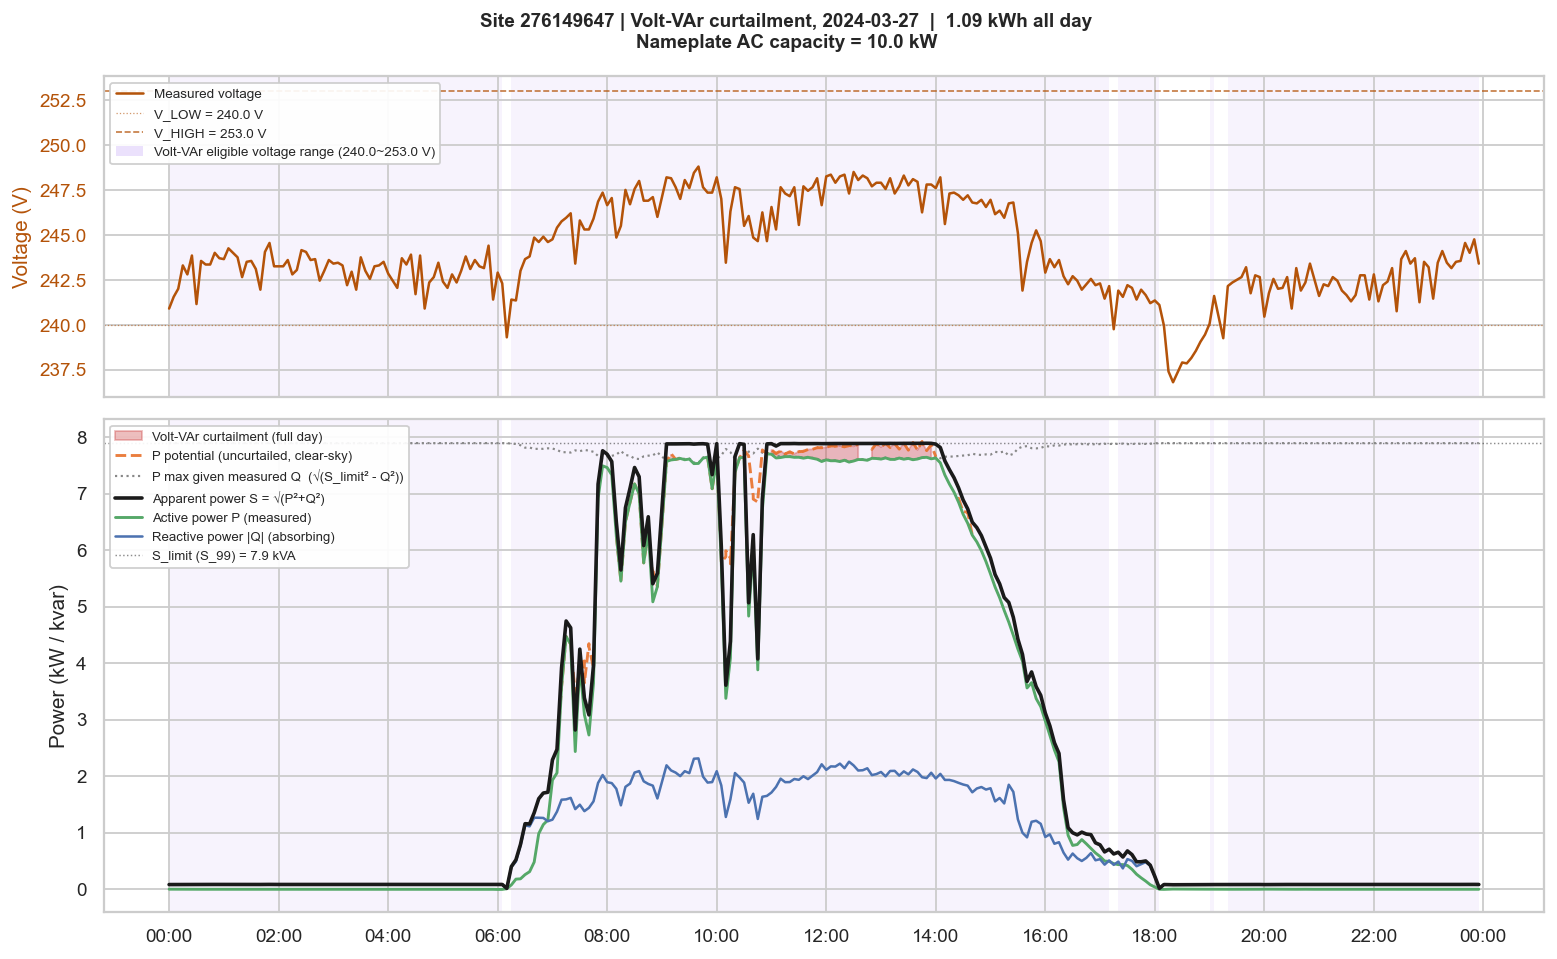

Curtailment within peak-hour window (11:00-13:00): 0.62 kWh
Curtailment across the full day:                       1.09 kWh


In [11]:
def plot_varcurt_day(site_id, date_str, ac_capacity_kw, s_limit, year=None,
                     restrict_to_peak_hours=False):
    """
    Full-day plot: voltage panel + power panel showing S, P, |Q|, P_potential,
    P_max_given_Q, and the explicit Volt-VAr curtailment area (shaded red) — the
    gap between P_potential and P_max_given_Q, which is the actual varcurt_kW
    quantity. Peak-solar window is marked directly on the x-axis.

    restrict_to_peak_hours: if True (default), the red shading and kWh total
        only count curtailment within PARAMS['PEAK_HOUR_START']-['PEAK_HOUR_END']
        — matching exactly what Method A/B use for fleet screening. If False,
        shows curtailment across the whole day (useful to see whether VAr
        curtailment is happening outside the peak-hour proxy window too).
    date_str: 'YYYY-MM-DD'
    """
    year = int(date_str.split("-")[0])
    month = int(date_str.split("-")[1])

    day_df = aq(f"""
        WITH site_meta AS (
            SELECT DISTINCT circuit_id, circuit_polarity
            FROM meta_up23c WHERE is_pv = True AND site_id = {site_id}
        ),
        meas AS (
            SELECT
                t.t_stamp,
                max(t.voltage)                                           AS V,
                sum(t.power * sm.circuit_polarity / 1000.0)              AS P_kW,
                sum(t.energy_reactive * sm.circuit_polarity / 1000.0*12) AS Q_kvar
            FROM ts t
            JOIN site_meta sm ON t.circuit_id = sm.circuit_id
            WHERE t.year = {year} AND t.month = {month} AND t.is_pv = True
              AND date(t.t_stamp + interval '10' hour) = date '{date_str}'
            GROUP BY t.t_stamp
        )
        SELECT m.t_stamp, m.V, m.P_kW, m.Q_kvar, u.uncurtailed_P AS P_potential_kW
        FROM meas m
        LEFT JOIN all_uncurtailedpv u
          ON u.site_id = {site_id} AND u.t_stamp = m.t_stamp
        ORDER BY m.t_stamp
    """, database=SAI)

    if day_df.empty:
        print(f"No data for site {site_id} on {date_str}.")
        return

    day_df["t"] = (pd.to_datetime(day_df["t_stamp"])
                    .dt.tz_localize("UTC").dt.tz_convert(FIXED_OFFSET)
                    .dt.tz_localize(None))
    day_df["S_apparent"] = np.sqrt(day_df["P_kW"]**2 + day_df["Q_kvar"]**2)
    day_df["P_max_given_Q"] = np.sqrt(np.clip(s_limit**2 - day_df["Q_kvar"]**2, 0, None))

    V_LOW, V_HIGH = PARAMS["V_LOW"], PARAMS["V_HIGH"]
    PEAK_START, PEAK_END = PARAMS["PEAK_HOUR_START"], PARAMS["PEAK_HOUR_END"]

    eligible   = (day_df["V"] > V_LOW) & (day_df["V"] < V_HIGH)
    peak_solar = (day_df["t"].dt.hour >= PEAK_START) & (day_df["t"].dt.hour < PEAK_END)

    # the curtailment criteria — voltage band, absorbing, apparent-power-bound
    curtail_signal = (
        eligible & (day_df["Q_kvar"] < 0) &
        day_df["P_potential_kW"].notna() &
        (day_df["P_potential_kW"] > day_df["P_max_given_Q"] + 0.02)
    )

    # apply the peak-hour restriction (or not) — this now matches Method A/B
    curtailed = curtail_signal & peak_solar if restrict_to_peak_hours else curtail_signal

    day_df["varcurt_kW"] = np.where(
        curtailed, np.maximum(0, day_df["P_potential_kW"] - day_df["P_max_given_Q"]), 0
    )
    # also compute the "all-day" total for comparison, regardless of the toggle
    day_df["varcurt_kW_allday"] = np.where(
        curtail_signal, np.maximum(0, day_df["P_potential_kW"] - day_df["P_max_given_Q"]), 0
    )

    fig, axes = plt.subplots(2, 1, figsize=(12, 7.5), dpi=130, sharex=True,
                             gridspec_kw={"height_ratios": [1.3, 2]})
    pal = sns.color_palette("deep")
    C_V, C_P, C_Q, C_S, C_POT, C_CURT = "#b45309", pal[2], pal[0], "#1a1a1a", "#e8702a", "#c62828"

    for ax in axes:
        ax.fill_between(day_df["t"], 0, 1, where=eligible.values,
                        transform=ax.get_xaxis_transform(),
                        color="#7c3aed", alpha=0.06, linewidth=0, zorder=0)

    ax = axes[0]

    # Voltage traces
    v_line, = ax.plot(day_df["t"], day_df["V"], color=C_V, lw=1.4, label="Measured voltage")
    v_low_line = ax.axhline(V_LOW,  color=C_V, lw=0.7, ls=":",  alpha=0.6,
                            label=f"V_LOW = {V_LOW:.1f} V")
    v_high_line = ax.axhline(V_HIGH, color=C_V, lw=0.9, ls="--", alpha=0.8,
                            label=f"V_HIGH = {V_HIGH:.1f} V")

    # Legend handle for the violet shaded band
    eligible_patch = Patch(
        facecolor="#7c3aed",
        alpha=0.15,
        edgecolor="none",
        label=f"Volt-VAr eligible voltage range ({V_LOW:.1f}~{V_HIGH:.1f} V)"
    )

    ax.set_ylabel("Voltage (V)", color=C_V)
    ax.tick_params(axis="y", colors=C_V)

    ax.legend(
        handles=[v_line, v_low_line, v_high_line, eligible_patch],
        fontsize=7.5,
        loc="upper left",
        framealpha=0.92
    )

    ax = axes[1]
    curt_label = ("Volt-VAr curtailment (peak-hour only)"
                 if restrict_to_peak_hours else
                 "Volt-VAr curtailment (full day)")
    ax.fill_between(day_df["t"], day_df["P_max_given_Q"], day_df["P_potential_kW"],
                    where=curtailed.values, color=C_CURT, alpha=0.30, zorder=2,
                    label=curt_label)

    if day_df["P_potential_kW"].notna().any():
        ax.plot(day_df["t"], day_df["P_potential_kW"], color=C_POT, lw=1.6, ls="--",
                alpha=0.9, zorder=4, label="P potential (uncurtailed, clear-sky)")
    ax.plot(day_df["t"], day_df["P_max_given_Q"], color="#888888", lw=1.2, ls=":",
            zorder=3, label="P max given measured Q  (√(S_limit² - Q²))")
    ax.plot(day_df["t"], day_df["S_apparent"], color=C_S, lw=2.0, zorder=5,
            label="Apparent power S = √(P²+Q²)")
    ax.plot(day_df["t"], day_df["P_kW"], color=C_P, lw=1.6, zorder=4,
            label="Active power P (measured)")
    ax.plot(day_df["t"], day_df["Q_kvar"].abs(), color=C_Q, lw=1.4, zorder=4,
            label="Reactive power |Q| (absorbing)")
    ax.axhline(s_limit, color=C_S, lw=0.8, ls=":", alpha=0.5,
              label=f"S_limit (S_99) = {s_limit:.1f} kVA")

    ax.set_ylabel("Power (kW / kvar)")
    ax.legend(fontsize=7.3, loc="upper left", framealpha=0.92, ncol=1)



    ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))
    fig.autofmt_xdate(rotation=0, ha="center")

    total_kwh        = (day_df["varcurt_kW"] * AS4777["INTERVAL_H"]).sum()
    total_kwh_allday = (day_df["varcurt_kW_allday"] * AS4777["INTERVAL_H"]).sum()

    window_note = (f"{total_kwh:.2f} kWh in peak window"
                   if restrict_to_peak_hours else
                   f"{total_kwh:.2f} kWh all day")
    fig.suptitle(
        f"Site {site_id} | Volt-VAr curtailment, {date_str}  |  {window_note}\n"
        f"Nameplate AC capacity = {ac_capacity_kw:.1f} kW",
#        f"peak-solar window ({PEAK_START}:00-{PEAK_END}:00) marked on x-axis",
        fontsize=10.5, fontweight="bold", y=0.98,
    )
    plt.tight_layout()
    plt.show()

    print(f"Curtailment within peak-hour window ({PEAK_START}:00-{PEAK_END}:00): "
          f"{total_kwh if restrict_to_peak_hours else (day_df['varcurt_kW_allday']*AS4777['INTERVAL_H'])[peak_solar].sum():.2f} kWh")
    print(f"Curtailment across the full day:                       {total_kwh_allday:.2f} kWh")


# pick the day with the most flagged intervals for TARGET_SITE
if 'varcurt' in dir() and len(varcurt):
    varcurt["t_local"] = (pd.to_datetime(varcurt["t_stamp"])
                          .dt.tz_localize("UTC").dt.tz_convert(FIXED_OFFSET))
    best_date = (varcurt[varcurt["varcurt_kW"] > 0]
                .groupby(varcurt["t_local"].dt.date)["varcurt_kW"]
                .count().idxmax())
    print(f"Plotting {best_date} for site {TARGET_SITE} (most curtailment events)")
    s_limit_val = varcurt["s_limit"].iloc[0]
    plot_varcurt_day(TARGET_SITE, str(best_date), varcurt["ac_capacity_kw"].iloc[0],
                     s_limit_val, year=METHOD_B_YEAR,
                     restrict_to_peak_hours=False)   # set False to see the full-day picture
else:
    print("Run Section 4 (Method B) first to identify a site and date with curtailment.")

## 6. Visualising one site: the apparent-power circle

Each flagged interval plotted on the **P–Q plane**, with the apparent-power circle overlaid.

Points sitting **on** the circle (within the established 4% tolerance) are highlighted with a red ring. These are the intervals where the inverter is genuinely riding its apparent-power
limit while absorbing VAr, the clearest visual signature of VAr-induced curtailment. 

Colour encodes voltage, confirming it's the high-V intervals doing it.

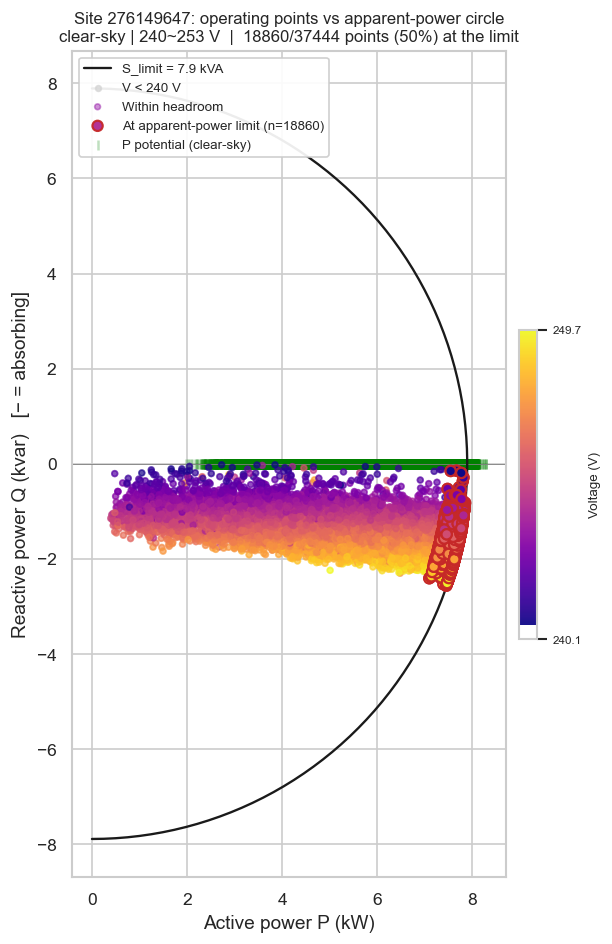

In [12]:
if 'varcurt' not in dir() or len(varcurt) == 0:
    print("No intervals to plot — run Section 4 (Method B) first.")
else:
    S   = varcurt["s_limit"].median()
    cap = varcurt["ac_capacity_kw"].median()
    tol = PARAMS["S_TOL_FRAC"] * cap

    S_apparent = np.sqrt(varcurt["P_meas_kW"]**2 + varcurt["Q_meas_kvar"]**2)
    on_circle = S_apparent >= (S - tol)

    # ---- voltage masks ----
    low_v = varcurt["V_max"] < 240
    normal_v = ~low_v

    # ---- figure layout ----
    fig = plt.figure(figsize=(7.5, 8.6), dpi=120)

    # main plot
    ax  = fig.add_axes([0.12, 0.12, 0.75, 0.80])

    # small vertical colorbar on the right
    cax = fig.add_axes([0.75, 0.35, 0.020, 0.30])


    # ---- apparent-power circle ----
    theta = np.linspace(-np.pi/2, np.pi/2, 200)
    ax.plot(
        S*np.cos(theta),
        S*np.sin(theta),
        color="k",
        lw=1.4,
        zorder=5,
        label=f"S_limit = {S:.1f} kVA"
    )

    # ---- low-voltage points (<240 V) in grey ----
    ax.scatter(
        varcurt.loc[low_v & ~on_circle, "P_meas_kW"],
        varcurt.loc[low_v & ~on_circle, "Q_meas_kvar"],
        color="lightgrey",
        s=12,
        alpha=0.7,
        zorder=2,
        label="V < 240 V"
    )

    ax.scatter(
        varcurt.loc[low_v & on_circle, "P_meas_kW"],
        varcurt.loc[low_v & on_circle, "Q_meas_kvar"],
        color="lightgrey",
        s=38,
        alpha=0.9,
        zorder=4,
        edgecolors="grey",
        linewidths=1.0
    )

    # ---- coloured points not at limit ----
    ax.scatter(
        varcurt.loc[normal_v & ~on_circle, "P_meas_kW"],
        varcurt.loc[normal_v & ~on_circle, "Q_meas_kvar"],
        c=varcurt.loc[normal_v & ~on_circle, "V_max"],
        cmap="plasma",
        s=12,
        alpha=0.45,
        zorder=3,
        label="Within headroom"
    )

    # ---- coloured points at limit ----
    sc = ax.scatter(
        varcurt.loc[normal_v & on_circle, "P_meas_kW"],
        varcurt.loc[normal_v & on_circle, "Q_meas_kvar"],
        c=varcurt.loc[normal_v & on_circle, "V_max"],
        cmap="plasma",
        s=38,
        alpha=0.95,
        zorder=6,
        edgecolors="#c62828",
        linewidths=1.3,
        label=f"At apparent-power limit (n={on_circle.sum()})"
    )

    # ---- potential power markers ----
    ax.scatter(
        varcurt["P_potential_kW"],
        np.zeros(len(varcurt)),
        marker="|",
        color="green",
        s=40,
        alpha=0.25,
        label="P potential (clear-sky)"
    )

    ax.axhline(0, color="grey", lw=0.5)

    ax.set_xlabel("Active power P (kW)")
    ax.set_ylabel("Reactive power Q (kvar)   [− = absorbing]")

    ax.set_title(
        f"Site {TARGET_SITE}: operating points vs apparent-power circle\n"
        f"clear-sky | {PARAMS['V_LOW']:.0f}~{PARAMS['V_HIGH']:.0f} V  |  "
        f"{on_circle.sum()}/{len(varcurt)} points ({on_circle.mean()*100:.0f}%) at the limit",
        fontsize=10,
    )

    ax.legend(loc="upper left", fontsize=8, framealpha=0.92)
    ax.set_aspect("equal")

    # ---- compact vertical colorbar ----
    cbar = fig.colorbar(sc, cax=cax, orientation="vertical")

    vmin = varcurt.loc[normal_v, "V_max"].min()
    vmax = varcurt.loc[normal_v, "V_max"].max()

    cbar.set_ticks([vmin, vmax])
    cbar.set_ticklabels([f"{vmin:.1f}", f"{vmax:.1f}"])
    cbar.set_label("Voltage (V)", fontsize=8)
    cbar.ax.tick_params(labelsize=7)

    plt.show()

## 7. Fleet summary: how often does this happen, in context

 This section adds three pieces of context: 
 - the **size of the eligible fleet** (sites that ever appear in the 240~253V/peak-solar window, regardless of whether they're flagged), 
 - the**total eligible generation** in that window (from `all_uncurtailedpv`, used as the denominator for "what fraction of potential generation was lost"), and 
 - the resulting **% of sites affected** and **% of eligible generation curtailed**.

In [13]:
# =============================================================================
# FLEET-WIDE VOLT-VAR CURTAILMENT SUMMARY
# Standardised denominators across PARAMS["YEARS"]
#
# Adds:
#   - eligible timestamp denominator
#   - all timestamp denominator
#   - eligible potential generation denominator
#   - all potential generation denominator
#
# Main metrics:
#   1. flagged intervals / eligible intervals
#   2. flagged intervals / all intervals
#   3. estimated curtailed energy, kWh
#   4. estimated curtailed energy / eligible potential generation
#   5. estimated curtailed energy / all potential generation
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# -------------------------------------------------------------------------
# Helper 1: eligible denominator query for one year
#
# Same eligibility conditions as Method A, but WITHOUT:
#   - Q_kvar < 0
#   - apparent power at/near limit
# -------------------------------------------------------------------------

def fetch_eligible_context_for_year(year, apply_ghi_filter):
    P = PARAMS
    _limit_col = "s_99" if P["USE_S99"] else "ac_capacity_kw"

    phase_cte   = ""
    phase_join  = ""
    phase_where = ""

    if P["PHASE_FILTER"] != "all":
        op = "= 1" if P["PHASE_FILTER"] == "single" else "> 1"

        phase_cte = f""",
        circuit_counts AS (
            SELECT
                site_id,
                count(DISTINCT circuit_id) AS n_circuits
            FROM meta_up23c
            WHERE is_pv = True
            GROUP BY site_id
        )
        """

        phase_join = """
            JOIN circuit_counts cc
              ON sm.site_id = cc.site_id
        """

        phase_where = f"""
              AND cc.n_circuits {op}
        """

    if apply_ghi_filter and HAS_GHI:
        ghi_join = """
            JOIN structured_data sd
              ON d.site_id = sd.site_id
             AND d.t_stamp = sd.t_stamp
        """

        ghi_filter = f"""
              AND sd.ghi_cs > 0
              AND sd.ghi / sd.ghi_cs >= {P['GHI_CS_RATIO_MIN']}
        """
    else:
        ghi_join = ""
        ghi_filter = ""

    sql = f"""
        WITH site_meta AS (
            SELECT DISTINCT
                site_id,
                circuit_id,
                circuit_polarity,
                ac_capacity_kw,
                {_limit_col} AS s_limit
            FROM meta_up23c
            WHERE is_pv = True
              AND {_limit_col} > 0
              AND ac_capacity_kw > 0
              AND ac_capacity_kw <= {P['MAX_AC_CAPACITY_KW']}
        )
        {phase_cte},

        d AS (
            SELECT
                t.circuit_id,
                t.t_stamp,
                sm.site_id,
                t.voltage
            FROM ts t
            JOIN site_meta sm
              ON t.circuit_id = sm.circuit_id
            {phase_join}
            WHERE t.year = {year}
              AND t.is_pv = True
              AND t.voltage > {P['V_LOW']}
              AND t.voltage < {P['V_HIGH']}
              {phase_where}
        ),

        site_interval AS (
            SELECT
                d.site_id,
                d.t_stamp,
                max(d.voltage) AS V_max
            FROM d
            {ghi_join}
            WHERE hour(d.t_stamp + interval '10' hour)
                  BETWEEN {P['PEAK_HOUR_START']} AND {P['PEAK_HOUR_END']}
              {ghi_filter}
            GROUP BY
                d.site_id,
                d.t_stamp
        )

        SELECT
            {year} AS year,
            si.site_id,
            count(*) AS n_eligible_intervals,
            round(
                sum(coalesce(u.uncurtailed_P, 0)) * {AS4777['INTERVAL_H']},
                3
            ) AS eligible_potential_kWh
        FROM site_interval si
        LEFT JOIN all_uncurtailedpv u
          ON u.site_id = si.site_id
         AND u.t_stamp = si.t_stamp
        GROUP BY
            si.site_id
    """

    return aq(sql, database=SAI)


# -------------------------------------------------------------------------
# Helper 2: all timestamp denominator query for one year
#
# Same site/phase/limit filters as Method A, but WITHOUT:
#   - voltage band
#   - peak-hour window
#   - GHI clear-sky filter
#   - Q_kvar < 0
#   - apparent power at/near limit
#
# This represents all observed PV site-timestamps in the year for the
# comparable fleet.
# -------------------------------------------------------------------------

def fetch_all_timestamp_context_for_year(year):
    P = PARAMS
    _limit_col = "s_99" if P["USE_S99"] else "ac_capacity_kw"

    phase_cte   = ""
    phase_join  = ""
    phase_where = ""

    if P["PHASE_FILTER"] != "all":
        op = "= 1" if P["PHASE_FILTER"] == "single" else "> 1"

        phase_cte = f""",
        circuit_counts AS (
            SELECT
                site_id,
                count(DISTINCT circuit_id) AS n_circuits
            FROM meta_up23c
            WHERE is_pv = True
            GROUP BY site_id
        )
        """

        phase_join = """
            JOIN circuit_counts cc
              ON sm.site_id = cc.site_id
        """

        phase_where = f"""
              AND cc.n_circuits {op}
        """

    sql = f"""
        WITH site_meta AS (
            SELECT DISTINCT
                site_id,
                circuit_id,
                circuit_polarity,
                ac_capacity_kw,
                {_limit_col} AS s_limit
            FROM meta_up23c
            WHERE is_pv = True
              AND ac_capacity_kw > 0
              AND ac_capacity_kw <= {P['MAX_AC_CAPACITY_KW']}
              AND {_limit_col} > 0
        )
        {phase_cte},

        d AS (
            SELECT
                t.circuit_id,
                t.t_stamp,
                sm.site_id
            FROM ts t
            JOIN site_meta sm
              ON t.circuit_id = sm.circuit_id
            {phase_join}
            WHERE t.year = {year}
              AND t.is_pv = True
              {phase_where}
        ),

        site_interval AS (
            SELECT
                d.site_id,
                d.t_stamp
            FROM d
            GROUP BY
                d.site_id,
                d.t_stamp
        )

        SELECT
            {year} AS year,
            si.site_id,
            count(*) AS n_all_intervals,
            round(
                sum(coalesce(u.uncurtailed_P, 0)) * {AS4777['INTERVAL_H']},
                3
            ) AS all_potential_kWh
        FROM site_interval si
        LEFT JOIN all_uncurtailedpv u
          ON u.site_id = si.site_id
         AND u.t_stamp = si.t_stamp
        GROUP BY
            si.site_id
    """

    return aq(sql, database=SAI)


# -------------------------------------------------------------------------
# Build denominator tables
# -------------------------------------------------------------------------

_eligible_context_year_results = []
_all_context_year_results = []

for _year in PARAMS["YEARS"]:
    _apply_ghi = HAS_GHI and (_year in PARAMS["GHI_YEARS"])

    print(
        f"Eligible denominator year {_year}: "
        f"clear-sky GHI filter {'ON' if _apply_ghi else 'OFF (peak-hour proxy only)'}"
    )

    _eligible_ctx = fetch_eligible_context_for_year(
        year=_year,
        apply_ghi_filter=_apply_ghi
    )

    _eligible_ctx["year"] = _year
    _eligible_ctx["ghi_filtered"] = _apply_ghi

    _eligible_context_year_results.append(_eligible_ctx)

    print(f"All-timestamp denominator year {_year}: all observed PV timestamps")

    _all_ctx = fetch_all_timestamp_context_for_year(year=_year)
    _all_ctx["year"] = _year

    _all_context_year_results.append(_all_ctx)


eligible_context_by_site_year = pd.concat(
    _eligible_context_year_results,
    ignore_index=True
)

all_context_by_site_year = pd.concat(
    _all_context_year_results,
    ignore_index=True
)


# Backwards-compatible alias, in case later notebook cells expect this name
fleet_context_by_site_year = eligible_context_by_site_year.copy()


# -------------------------------------------------------------------------
# Numerator table by year
# -------------------------------------------------------------------------

curtailment_by_year = (
    _all_years
    .groupby("year", as_index=False)
    .agg(
        affected_sites=("site_id", "nunique"),
        flagged_intervals=("n_flagged_intervals", "sum"),
        est_curtailed_kWh=("est_curtailed_kWh", "sum")
    )
)


# -------------------------------------------------------------------------
# Denominator tables by year
# -------------------------------------------------------------------------

eligible_denominator_by_year = (
    eligible_context_by_site_year
    .groupby("year", as_index=False)
    .agg(
        eligible_sites=("site_id", "nunique"),
        eligible_intervals=("n_eligible_intervals", "sum"),
        eligible_potential_kWh=("eligible_potential_kWh", "sum")
    )
)

all_denominator_by_year = (
    all_context_by_site_year
    .groupby("year", as_index=False)
    .agg(
        all_sites=("site_id", "nunique"),
        all_intervals=("n_all_intervals", "sum"),
        all_potential_kWh=("all_potential_kWh", "sum")
    )
)


# -------------------------------------------------------------------------
# Combine numerator and denominators year-by-year
# -------------------------------------------------------------------------

summary_by_year = (
    all_denominator_by_year
    .merge(eligible_denominator_by_year, on="year", how="left")
    .merge(curtailment_by_year, on="year", how="left")
    .fillna({
        "eligible_sites": 0,
        "eligible_intervals": 0,
        "eligible_potential_kWh": 0,
        "affected_sites": 0,
        "flagged_intervals": 0,
        "est_curtailed_kWh": 0
    })
)

int_cols = [
    "all_sites",
    "all_intervals",
    "eligible_sites",
    "eligible_intervals",
    "affected_sites",
    "flagged_intervals"
]

for col in int_cols:
    summary_by_year[col] = summary_by_year[col].astype(int)

summary_by_year["pct_eligible_sites_affected"] = np.where(
    summary_by_year["eligible_sites"] > 0,
    summary_by_year["affected_sites"] / summary_by_year["eligible_sites"] * 100,
    np.nan
)

summary_by_year["pct_eligible_intervals_flagged"] = np.where(
    summary_by_year["eligible_intervals"] > 0,
    summary_by_year["flagged_intervals"] / summary_by_year["eligible_intervals"] * 100,
    np.nan
)

summary_by_year["pct_all_intervals_flagged"] = np.where(
    summary_by_year["all_intervals"] > 0,
    summary_by_year["flagged_intervals"] / summary_by_year["all_intervals"] * 100,
    np.nan
)

summary_by_year["pct_eligible_potential_curtailed"] = np.where(
    summary_by_year["eligible_potential_kWh"] > 0,
    summary_by_year["est_curtailed_kWh"] / summary_by_year["eligible_potential_kWh"] * 100,
    np.nan
)

summary_by_year["pct_all_potential_curtailed"] = np.where(
    summary_by_year["all_potential_kWh"] > 0,
    summary_by_year["est_curtailed_kWh"] / summary_by_year["all_potential_kWh"] * 100,
    np.nan
)

summary_by_year["avg_est_curtailed_kW_when_flagged"] = np.where(
    summary_by_year["flagged_intervals"] > 0,
    summary_by_year["est_curtailed_kWh"] /
    (summary_by_year["flagged_intervals"] * AS4777["INTERVAL_H"]),
    np.nan
)


# -------------------------------------------------------------------------
# Build site-year distribution table
#
# Base table is all observed PV site-years.
# Eligible denominators are merged in.
# Curtailment numerators are merged in.
# -------------------------------------------------------------------------

curtailment_by_site_year = (
    _all_years
    .groupby(["site_id", "year"], as_index=False)
    .agg(
        n_flagged_intervals=("n_flagged_intervals", "sum"),
        avg_V=("avg_V", "mean"),
        avg_P_kW=("avg_P_kW", "mean"),
        avg_Q_kvar=("avg_Q_kvar", "mean"),
        avg_s_limit=("avg_s_limit", "mean"),
        est_curtailed_kWh=("est_curtailed_kWh", "sum")
    )
)

site_year_distribution = (
    all_context_by_site_year
    .merge(
        eligible_context_by_site_year,
        on=["site_id", "year"],
        how="left"
    )
    .merge(
        curtailment_by_site_year,
        on=["site_id", "year"],
        how="left"
    )
)

fill_zero_cols = [
    "n_eligible_intervals",
    "eligible_potential_kWh",
    "n_flagged_intervals",
    "est_curtailed_kWh"
]

for col in fill_zero_cols:
    site_year_distribution[col] = site_year_distribution[col].fillna(0)

site_year_distribution["n_all_intervals"] = (
    site_year_distribution["n_all_intervals"].astype(int)
)

site_year_distribution["n_eligible_intervals"] = (
    site_year_distribution["n_eligible_intervals"].astype(int)
)

site_year_distribution["n_flagged_intervals"] = (
    site_year_distribution["n_flagged_intervals"].astype(int)
)

site_year_distribution["is_eligible_site_year"] = (
    site_year_distribution["n_eligible_intervals"] > 0
)

site_year_distribution["is_affected_site_year"] = (
    site_year_distribution["n_flagged_intervals"] > 0
)

site_year_distribution["all_hours"] = (
    site_year_distribution["n_all_intervals"] * AS4777["INTERVAL_H"]
)

site_year_distribution["eligible_hours"] = (
    site_year_distribution["n_eligible_intervals"] * AS4777["INTERVAL_H"]
)

site_year_distribution["flagged_hours"] = (
    site_year_distribution["n_flagged_intervals"] * AS4777["INTERVAL_H"]
)

site_year_distribution["pct_eligible_timestamps_flagged"] = np.where(
    site_year_distribution["n_eligible_intervals"] > 0,
    site_year_distribution["n_flagged_intervals"] /
    site_year_distribution["n_eligible_intervals"] * 100,
    np.nan
)

site_year_distribution["pct_all_timestamps_flagged"] = np.where(
    site_year_distribution["n_all_intervals"] > 0,
    site_year_distribution["n_flagged_intervals"] /
    site_year_distribution["n_all_intervals"] * 100,
    np.nan
)

site_year_distribution["pct_eligible_potential_generation_curtailed"] = np.where(
    site_year_distribution["eligible_potential_kWh"] > 0,
    site_year_distribution["est_curtailed_kWh"] /
    site_year_distribution["eligible_potential_kWh"] * 100,
    np.nan
)

site_year_distribution["pct_all_potential_generation_curtailed"] = np.where(
    site_year_distribution["all_potential_kWh"] > 0,
    site_year_distribution["est_curtailed_kWh"] /
    site_year_distribution["all_potential_kWh"] * 100,
    np.nan
)

site_year_distribution["avg_est_curtailed_kW_when_flagged"] = np.where(
    site_year_distribution["n_flagged_intervals"] > 0,
    site_year_distribution["est_curtailed_kWh"] /
    (site_year_distribution["n_flagged_intervals"] * AS4777["INTERVAL_H"]),
    np.nan
)


# -------------------------------------------------------------------------
# Overall multi-year summary
# -------------------------------------------------------------------------

if len(candidates) == 0:
    print(
        "No candidate sites found. Loosen PARAMS, for example raise "
        "GHI_CS_RATIO_MIN tolerance or check S_TOL_FRAC."
    )

else:
    n_sites_affected = candidates["site_id"].nunique()
    total_flagged = candidates["n_flagged_intervals"].sum()
    total_est_kwh = candidates["est_curtailed_kWh"].sum()

    total_flagged_hours = total_flagged * AS4777["INTERVAL_H"]

    n_all_sites = all_context_by_site_year["site_id"].nunique()
    total_all_intervals = all_context_by_site_year["n_all_intervals"].sum()
    total_all_potential_kwh = all_context_by_site_year["all_potential_kWh"].sum()

    n_eligible_sites = eligible_context_by_site_year["site_id"].nunique()
    total_eligible_intervals = eligible_context_by_site_year["n_eligible_intervals"].sum()
    total_eligible_potential_kwh = eligible_context_by_site_year["eligible_potential_kWh"].sum()

    pct_sites_affected = (
        n_sites_affected / n_eligible_sites * 100
        if n_eligible_sites > 0
        else np.nan
    )

    pct_eligible_intervals_flagged = (
        total_flagged / total_eligible_intervals * 100
        if total_eligible_intervals > 0
        else np.nan
    )

    pct_all_intervals_flagged = (
        total_flagged / total_all_intervals * 100
        if total_all_intervals > 0
        else np.nan
    )

    pct_eligible_potential_curtailed = (
        total_est_kwh / total_eligible_potential_kwh * 100
        if total_eligible_potential_kwh > 0
        else np.nan
    )

    pct_all_potential_curtailed = (
        total_est_kwh / total_all_potential_kwh * 100
        if total_all_potential_kwh > 0
        else np.nan
    )

    avg_curtailed_kw_when_flagged = (
        total_est_kwh / total_flagged_hours
        if total_flagged_hours > 0
        else np.nan
    )

    print("=" * 88)
    print(f"VOLT-VAR CURTAILMENT — FLEET SUMMARY ({PARAMS['YEARS']})")
    print("=" * 88)
    print()
    print(
        f"Eligible case definition: peak-solar, "
        f"{PARAMS['V_LOW']:.0f}-{PARAMS['V_HIGH']:.0f} V, "
        f"same phase and limit filters as Method A"
    )
    print()
    print("Overall multi-year denominator — all timestamps:")
    print(f"  All comparable PV sites:                 {n_all_sites:,}")
    print(f"  All observed site-intervals:             {total_all_intervals:,}")
    print(f"  All potential generation:                {total_all_potential_kwh:,.0f} kWh")
    print()
    print("Overall multi-year denominator — eligible cases only:")
    print(f"  Eligible sites:                          {n_eligible_sites:,}")
    print(f"  Eligible site-intervals:                 {total_eligible_intervals:,}")
    print(f"  Eligible potential generation:           {total_eligible_potential_kwh:,.0f} kWh")
    print()
    print("Overall multi-year numerator:")
    print(
        f"  Sites showing VAr-curtailment symptom:   {n_sites_affected:,} "
        f"({pct_sites_affected:.1f}% of eligible fleet)"
    )
    print(f"  Total flagged intervals:                 {total_flagged:,}")
    print(f"  Total flagged hours:                     {total_flagged_hours:,.1f} h")
    print(f"  Share of eligible site-intervals:        {pct_eligible_intervals_flagged:.4f}%")
    print(f"  Share of all site-intervals:             {pct_all_intervals_flagged:.4f}%")
    print(f"  Est. energy curtailed, Method A:         {total_est_kwh:,.1f} kWh")
    print(f"  Avg est. curtailed power when flagged:   {avg_curtailed_kw_when_flagged:,.3f} kW")
    print(f"  Share of eligible potential generation: {pct_eligible_potential_curtailed:.4f}%")
    print(f"  Share of all potential generation:      {pct_all_potential_curtailed:.4f}%")
    print(f"  Median intervals per affected site:      {candidates['n_flagged_intervals'].median():.0f}")
    print()

    print("=" * 88)
    print("YEAR-BY-YEAR BREAKDOWN")
    print("=" * 88)

    display_cols = [
        "year",
        "all_sites",
        "all_intervals",
        "all_potential_kWh",
        "eligible_sites",
        "eligible_intervals",
        "eligible_potential_kWh",
        "affected_sites",
        "flagged_intervals",
        "est_curtailed_kWh",
        "pct_eligible_sites_affected",
        "pct_eligible_intervals_flagged",
        "pct_all_intervals_flagged",
        "pct_eligible_potential_curtailed",
        "pct_all_potential_curtailed",
        "avg_est_curtailed_kW_when_flagged"
    ]

    summary_by_year_display = summary_by_year[display_cols].copy()

    round_cols_1 = [
        "all_potential_kWh",
        "eligible_potential_kWh",
        "est_curtailed_kWh"
    ]

    round_cols_4 = [
        "pct_eligible_intervals_flagged",
        "pct_all_intervals_flagged",
        "pct_eligible_potential_curtailed",
        "pct_all_potential_curtailed"
    ]

    for col in round_cols_1:
        summary_by_year_display[col] = summary_by_year_display[col].round(1)

    summary_by_year_display["pct_eligible_sites_affected"] = (
        summary_by_year_display["pct_eligible_sites_affected"].round(2)
    )

    for col in round_cols_4:
        summary_by_year_display[col] = summary_by_year_display[col].round(4)

    summary_by_year_display["avg_est_curtailed_kW_when_flagged"] = (
        summary_by_year_display["avg_est_curtailed_kW_when_flagged"].round(3)
    )

    print(summary_by_year_display.to_string(index=False))
    print()

    print("=" * 88)
    print("TOP 10 MOST-AFFECTED SITES ACROSS ALL YEARS")
    print("=" * 88)

    top10 = (
        candidates
        .sort_values("est_curtailed_kWh", ascending=False)
        .head(10)
        .copy()
    )

    top10["avg_est_curtailed_kW_when_flagged"] = np.where(
        top10["n_flagged_intervals"] > 0,
        top10["est_curtailed_kWh"] /
        (top10["n_flagged_intervals"] * AS4777["INTERVAL_H"]),
        np.nan
    )

    print(
        top10[
            [
                "site_id",
                "n_flagged_intervals",
                "avg_V",
                "avg_P_kW",
                "avg_Q_kvar",
                "est_curtailed_kWh",
                "avg_est_curtailed_kW_when_flagged",
                "years_covered"
            ]
        ]
        .to_string(index=False)
    )

Eligible denominator year 2024: clear-sky GHI filter ON
All-timestamp denominator year 2024: all observed PV timestamps
Eligible denominator year 2025: clear-sky GHI filter ON
All-timestamp denominator year 2025: all observed PV timestamps
VOLT-VAR CURTAILMENT — FLEET SUMMARY ([2024, 2025])

Eligible case definition: peak-solar, 240-253 V, same phase and limit filters as Method A

Overall multi-year denominator — all timestamps:
  All comparable PV sites:                 15,526
  All observed site-intervals:             2,638,727,876
  All potential generation:                366,330,338 kWh

Overall multi-year denominator — eligible cases only:
  Eligible sites:                          14,652
  Eligible site-intervals:                 119,879,101
  Eligible potential generation:           47,804,359 kWh

Overall multi-year numerator:
  Sites showing VAr-curtailment symptom:   7,218 (49.3% of eligible fleet)
  Total flagged intervals:                 6,226,121
  Total flagged hours:  

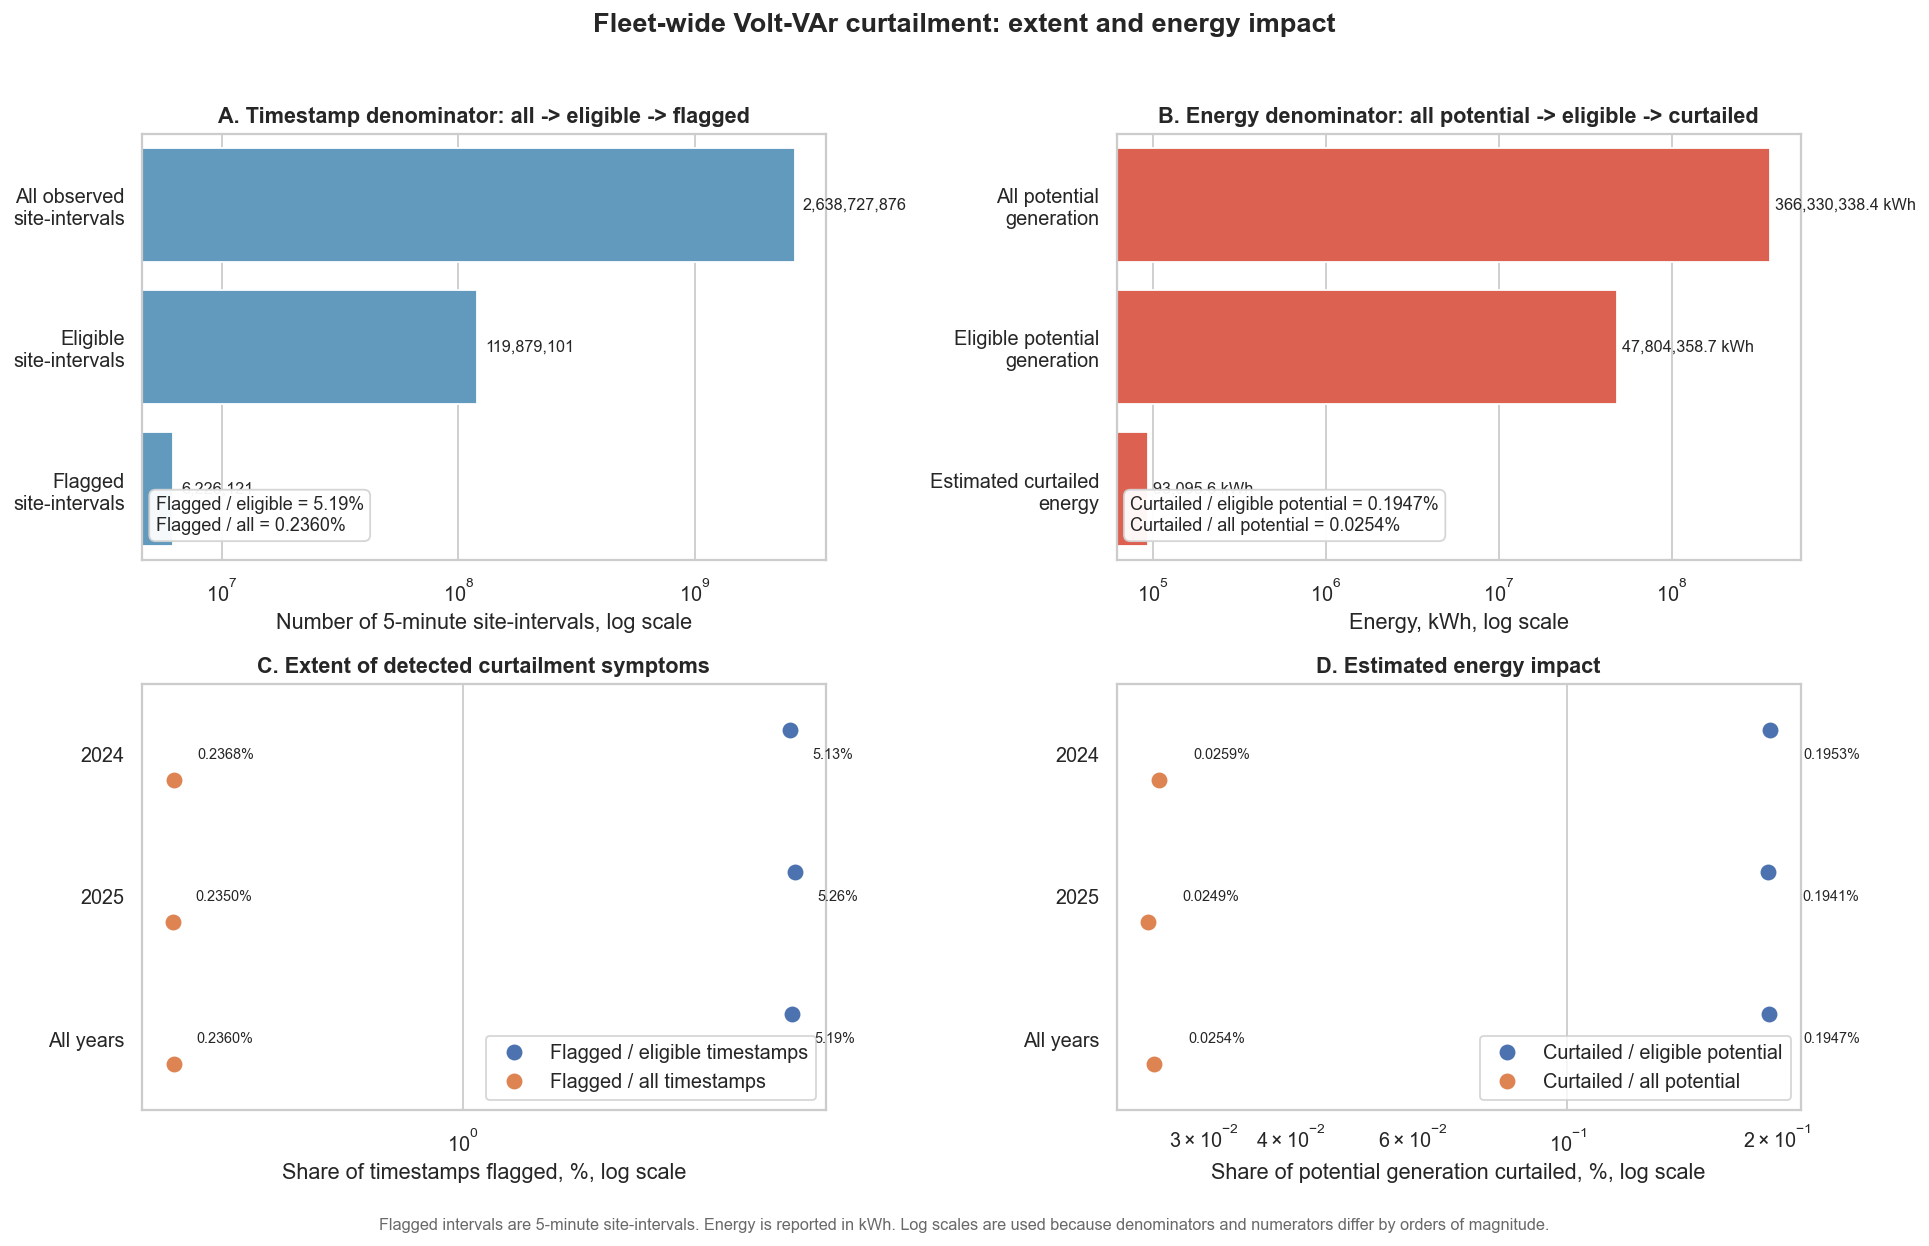

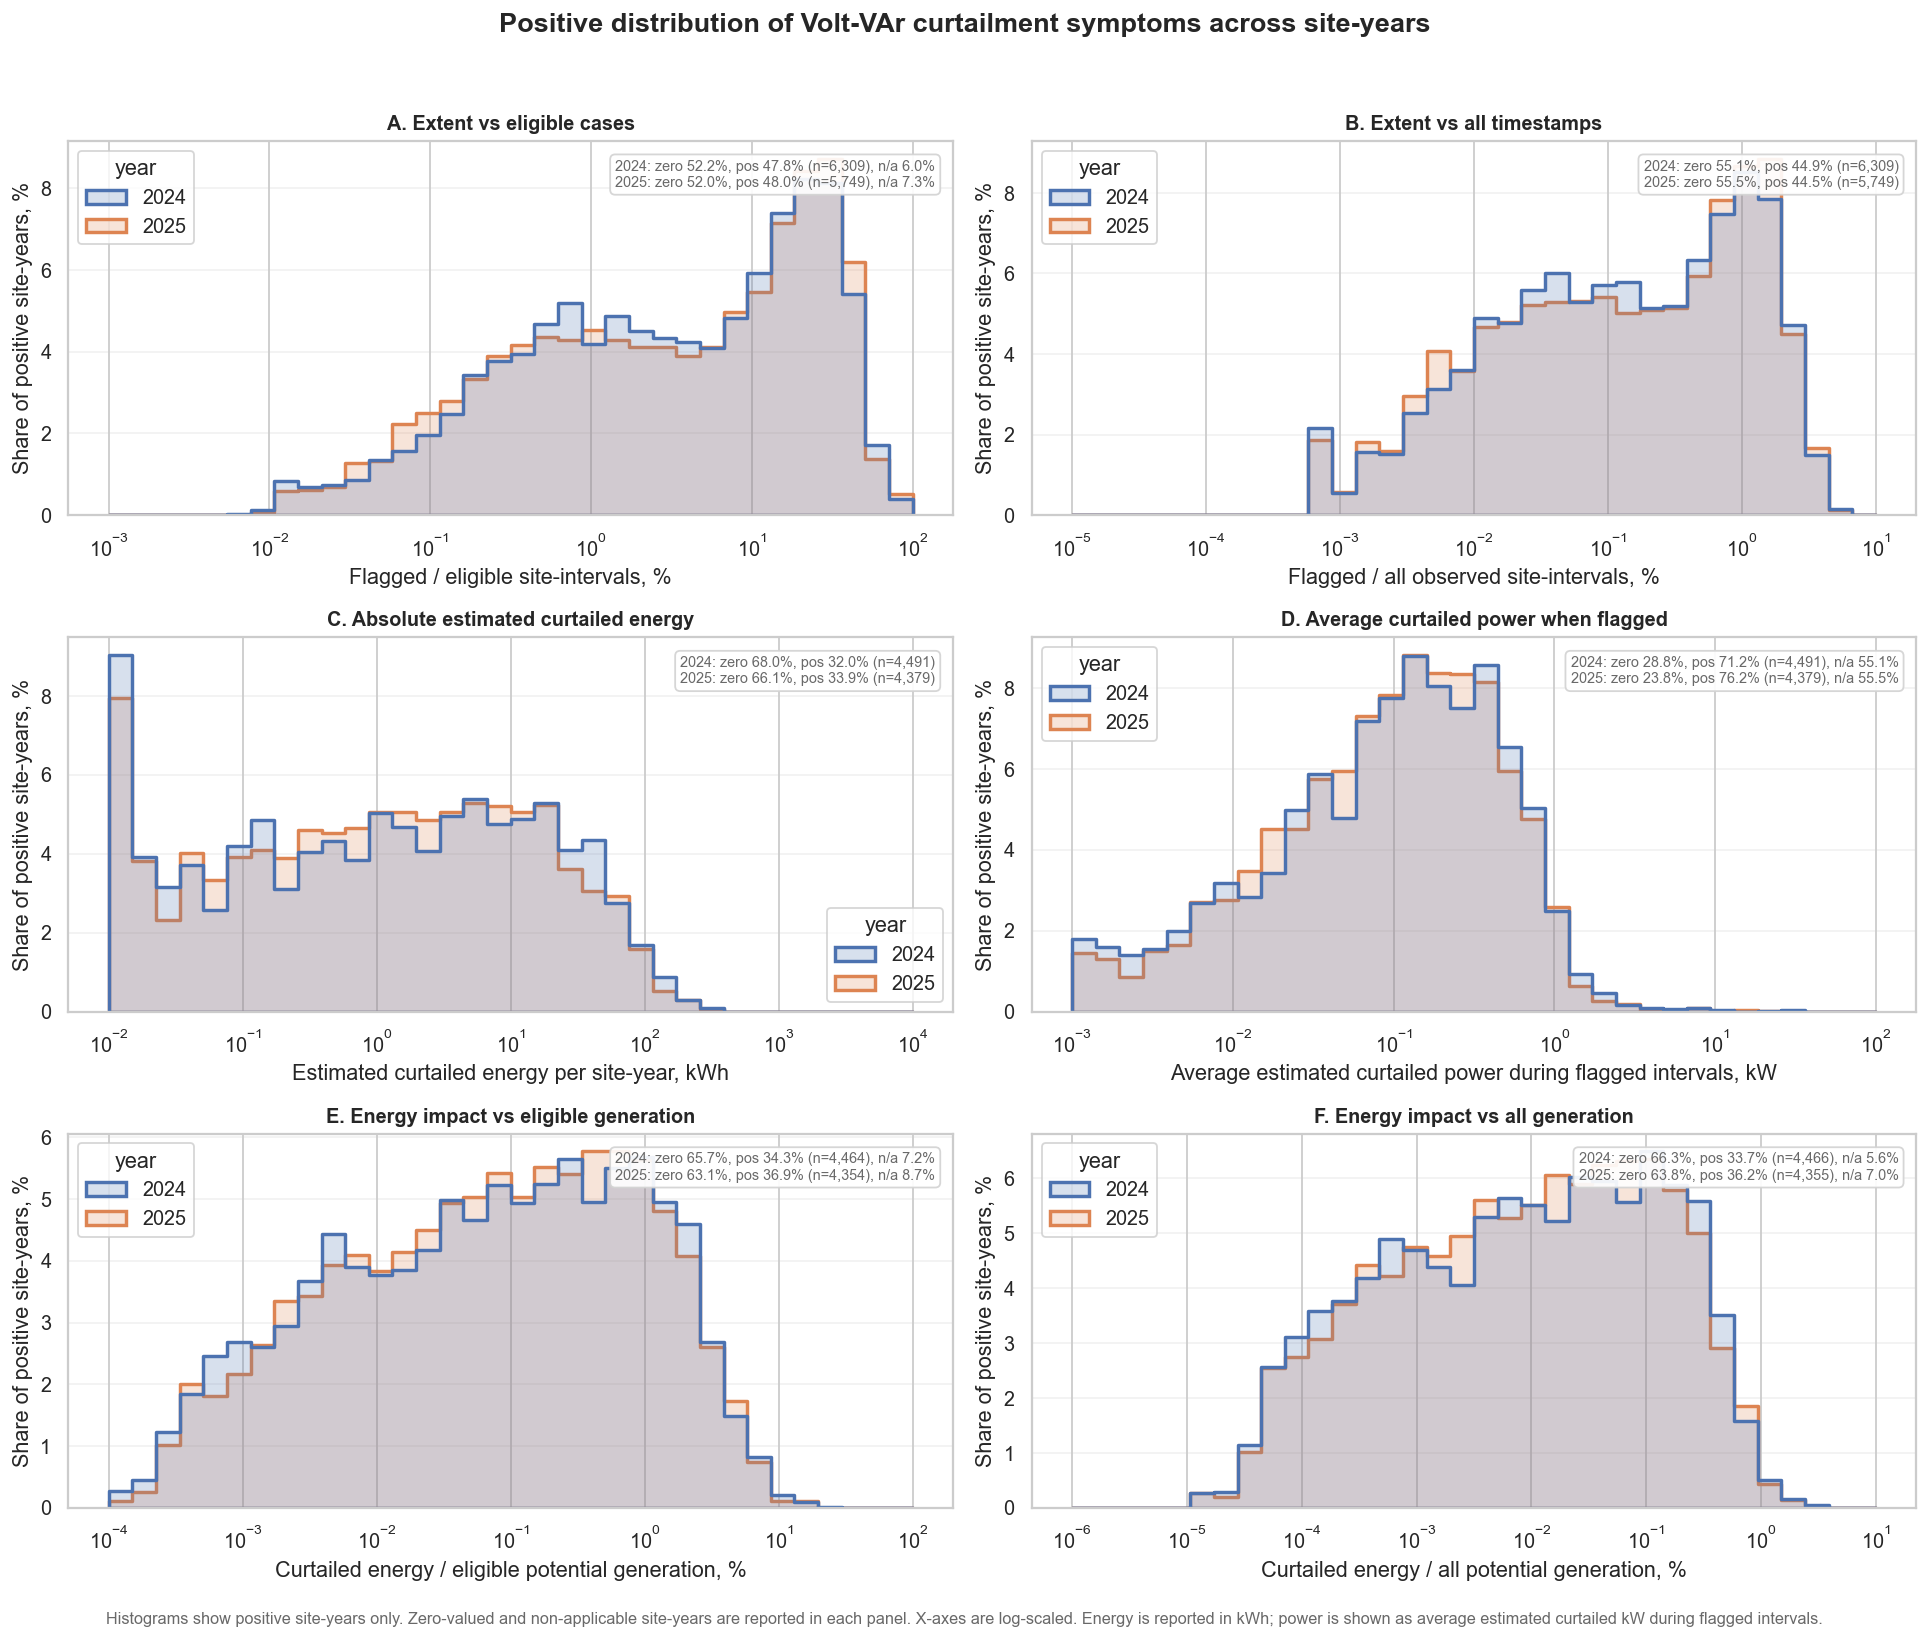

In [14]:
# =============================================================================
# VISUALISATION — CLEAN FLEET SUMMARY + POSITIVE-VALUE DISTRIBUTIONS
#
# Produces:
#   Figure 1: Compact fleet-level denominator summary
#   Figure 2: Positive-value distribution histograms
#
# Removes the previous percentile/range Figure 2.
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


# -------------------------------------------------------------------------
# Helper formatting
# -------------------------------------------------------------------------

def _fmt_num(x, decimals=1):
    if pd.isna(x):
        return "n/a"
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.{decimals}f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.{decimals}f}k"
    if abs(x) >= 10:
        return f"{x:,.0f}"
    if abs(x) >= 1:
        return f"{x:,.1f}"
    if abs(x) >= 0.01:
        return f"{x:,.3f}"
    return f"{x:,.5f}"


def _fmt_pct(x, decimals=4):
    if pd.isna(x):
        return "n/a"
    if abs(x) >= 10:
        return f"{x:.1f}%"
    if abs(x) >= 1:
        return f"{x:.2f}%"
    return f"{x:.{decimals}f}%"


# -------------------------------------------------------------------------
# Build overall summary row for plotting
# -------------------------------------------------------------------------

overall_summary = pd.DataFrame([{
    "year": "All years",
    "all_sites": all_context_by_site_year["site_id"].nunique(),
    "all_intervals": all_context_by_site_year["n_all_intervals"].sum(),
    "all_potential_kWh": all_context_by_site_year["all_potential_kWh"].sum(),
    "eligible_sites": eligible_context_by_site_year["site_id"].nunique(),
    "eligible_intervals": eligible_context_by_site_year["n_eligible_intervals"].sum(),
    "eligible_potential_kWh": eligible_context_by_site_year["eligible_potential_kWh"].sum(),
    "affected_sites": candidates["site_id"].nunique(),
    "flagged_intervals": candidates["n_flagged_intervals"].sum(),
    "est_curtailed_kWh": candidates["est_curtailed_kWh"].sum()
}])

overall_summary["pct_eligible_intervals_flagged"] = np.where(
    overall_summary["eligible_intervals"] > 0,
    overall_summary["flagged_intervals"] / overall_summary["eligible_intervals"] * 100,
    np.nan
)

overall_summary["pct_all_intervals_flagged"] = np.where(
    overall_summary["all_intervals"] > 0,
    overall_summary["flagged_intervals"] / overall_summary["all_intervals"] * 100,
    np.nan
)

overall_summary["pct_eligible_potential_curtailed"] = np.where(
    overall_summary["eligible_potential_kWh"] > 0,
    overall_summary["est_curtailed_kWh"] / overall_summary["eligible_potential_kWh"] * 100,
    np.nan
)

overall_summary["pct_all_potential_curtailed"] = np.where(
    overall_summary["all_potential_kWh"] > 0,
    overall_summary["est_curtailed_kWh"] / overall_summary["all_potential_kWh"] * 100,
    np.nan
)

overall_summary["avg_est_curtailed_kW_when_flagged"] = np.where(
    overall_summary["flagged_intervals"] > 0,
    overall_summary["est_curtailed_kWh"] /
    (overall_summary["flagged_intervals"] * AS4777["INTERVAL_H"]),
    np.nan
)

summary_plot_df = pd.concat(
    [
        summary_by_year.assign(year=summary_by_year["year"].astype(str)),
        overall_summary
    ],
    ignore_index=True
)


# =============================================================================
# FIGURE 1 — CLEAN FLEET-LEVEL DENOMINATOR SUMMARY
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 9), dpi=130)

# -------------------------------------------------------------------------
# A. Timestamp denominator funnel
# -------------------------------------------------------------------------

ax = axes[0, 0]

timestamp_values = pd.DataFrame({
    "category": [
        "All observed\nsite-intervals",
        "Eligible\nsite-intervals",
        "Flagged\nsite-intervals"
    ],
    "value": [
        overall_summary["all_intervals"].iloc[0],
        overall_summary["eligible_intervals"].iloc[0],
        overall_summary["flagged_intervals"].iloc[0]
    ]
})

sns.barplot(
    data=timestamp_values,
    y="category",
    x="value",
    orient="h",
    color=sns.color_palette("Blues")[3],
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Number of 5-minute site-intervals, log scale")
ax.set_ylabel("")
ax.set_title("A. Timestamp denominator: all -> eligible -> flagged", weight="bold")

for i, r in timestamp_values.iterrows():
    ax.text(
        r["value"] * 1.08,
        i,
        f"{r['value']:,.0f}",
        va="center",
        fontsize=9
    )

ax.text(
    0.02,
    0.06,
    f"Flagged / eligible = {_fmt_pct(overall_summary['pct_eligible_intervals_flagged'].iloc[0])}\n"
    f"Flagged / all = {_fmt_pct(overall_summary['pct_all_intervals_flagged'].iloc[0])}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="lightgrey",
        alpha=0.95
    )
)

# -------------------------------------------------------------------------
# B. Energy denominator funnel
# -------------------------------------------------------------------------

ax = axes[0, 1]

energy_values = pd.DataFrame({
    "category": [
        "All potential\ngeneration",
        "Eligible potential\ngeneration",
        "Estimated curtailed\nenergy"
    ],
    "value": [
        overall_summary["all_potential_kWh"].iloc[0],
        overall_summary["eligible_potential_kWh"].iloc[0],
        overall_summary["est_curtailed_kWh"].iloc[0]
    ]
})

sns.barplot(
    data=energy_values,
    y="category",
    x="value",
    orient="h",
    color=sns.color_palette("Reds")[3],
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Energy, kWh, log scale")
ax.set_ylabel("")
ax.set_title("B. Energy denominator: all potential -> eligible -> curtailed", weight="bold")

for i, r in energy_values.iterrows():
    ax.text(
        r["value"] * 1.08,
        i,
        f"{r['value']:,.1f} kWh",
        va="center",
        fontsize=9
    )

ax.text(
    0.02,
    0.06,
    f"Curtailed / eligible potential = {_fmt_pct(overall_summary['pct_eligible_potential_curtailed'].iloc[0])}\n"
    f"Curtailed / all potential = {_fmt_pct(overall_summary['pct_all_potential_curtailed'].iloc[0])}",
    transform=ax.transAxes,
    ha="left",
    va="bottom",
    fontsize=10,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="lightgrey",
        alpha=0.95
    )
)

# -------------------------------------------------------------------------
# C. Year-by-year timestamp rates
# -------------------------------------------------------------------------

ax = axes[1, 0]

rate_df = (
    summary_plot_df[[
        "year",
        "pct_eligible_intervals_flagged",
        "pct_all_intervals_flagged"
    ]]
    .melt(
        id_vars="year",
        var_name="metric",
        value_name="percent"
    )
)

rate_df["metric"] = rate_df["metric"].map({
    "pct_eligible_intervals_flagged": "Flagged / eligible timestamps",
    "pct_all_intervals_flagged": "Flagged / all timestamps"
})

sns.pointplot(
    data=rate_df,
    x="percent",
    y="year",
    hue="metric",
    dodge=0.35,
    markers="o",
    linestyles="",
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Share of timestamps flagged, %, log scale")
ax.set_ylabel("")
ax.set_title("C. Extent of detected curtailment symptoms", weight="bold")
ax.legend(title="", loc="lower right", frameon=True)

for _, r in rate_df.iterrows():
    if pd.notna(r["percent"]) and r["percent"] > 0:
        ax.text(
            r["percent"] * 1.12,
            list(summary_plot_df["year"]).index(r["year"]),
            _fmt_pct(r["percent"]),
            va="center",
            fontsize=8
        )

# -------------------------------------------------------------------------
# D. Year-by-year energy rates
# -------------------------------------------------------------------------

ax = axes[1, 1]

energy_rate_df = (
    summary_plot_df[[
        "year",
        "pct_eligible_potential_curtailed",
        "pct_all_potential_curtailed"
    ]]
    .melt(
        id_vars="year",
        var_name="metric",
        value_name="percent"
    )
)

energy_rate_df["metric"] = energy_rate_df["metric"].map({
    "pct_eligible_potential_curtailed": "Curtailed / eligible potential",
    "pct_all_potential_curtailed": "Curtailed / all potential"
})

sns.pointplot(
    data=energy_rate_df,
    x="percent",
    y="year",
    hue="metric",
    dodge=0.35,
    markers="o",
    linestyles="",
    ax=ax
)

ax.set_xscale("log")
ax.set_xlabel("Share of potential generation curtailed, %, log scale")
ax.set_ylabel("")
ax.set_title("D. Estimated energy impact", weight="bold")
ax.legend(title="", loc="lower right", frameon=True)

for _, r in energy_rate_df.iterrows():
    if pd.notna(r["percent"]) and r["percent"] > 0:
        ax.text(
            r["percent"] * 1.12,
            list(summary_plot_df["year"]).index(r["year"]),
            _fmt_pct(r["percent"]),
            va="center",
            fontsize=8
        )

fig.suptitle(
    "Fleet-wide Volt-VAr curtailment: extent and energy impact",
    fontsize=15,
    weight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.01,
    "Flagged intervals are 5-minute site-intervals. Energy is reported in kWh. "
    "Log scales are used because denominators and numerators differ by orders of magnitude.",
    ha="center",
    va="top",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.show()


# =============================================================================
# FIGURE 2 — POSITIVE-VALUE DISTRIBUTIONS
#
# Histograms show positive site-years only.
# Zero-valued and non-applicable site-years are reported in each annotation.
#
# This replaces the previous percentile/range Figure 2.
# =============================================================================

plot_df = site_year_distribution.copy().reset_index(drop=True)
plot_df["year"] = plot_df["year"].astype(str)

# Defensive renaming/aliasing in case older notebook versions still have
# pct_potential_generation_curtailed rather than the new eligible/all names.
if (
    "pct_eligible_potential_generation_curtailed" not in plot_df.columns
    and "pct_potential_generation_curtailed" in plot_df.columns
):
    plot_df["pct_eligible_potential_generation_curtailed"] = (
        plot_df["pct_potential_generation_curtailed"]
    )

# Main distribution metrics requested
distribution_metrics = {
    "pct_eligible_timestamps_flagged": {
        "title": "A. Extent vs eligible cases",
        "xlabel": "Flagged / eligible site-intervals, %",
        "bins": np.logspace(-3, 2, 35),
        "denominator_col": "n_eligible_intervals"
    },
    "pct_all_timestamps_flagged": {
        "title": "B. Extent vs all timestamps",
        "xlabel": "Flagged / all observed site-intervals, %",
        "bins": np.logspace(-5, 1, 35),
        "denominator_col": "n_all_intervals"
    },
    "est_curtailed_kWh": {
        "title": "C. Absolute estimated curtailed energy",
        "xlabel": "Estimated curtailed energy per site-year, kWh",
        "bins": np.logspace(-2, 4, 35),
        "denominator_col": "n_all_intervals"
    },
    "avg_est_curtailed_kW_when_flagged": {
        "title": "D. Average curtailed power when flagged",
        "xlabel": "Average estimated curtailed power during flagged intervals, kW",
        "bins": np.logspace(-3, 2, 35),
        "denominator_col": "n_flagged_intervals"
    },
    "pct_eligible_potential_generation_curtailed": {
        "title": "E. Energy impact vs eligible generation",
        "xlabel": "Curtailed energy / eligible potential generation, %",
        "bins": np.logspace(-4, 2, 35),
        "denominator_col": "eligible_potential_kWh"
    },
    "pct_all_potential_generation_curtailed": {
        "title": "F. Energy impact vs all generation",
        "xlabel": "Curtailed energy / all potential generation, %",
        "bins": np.logspace(-6, 1, 35),
        "denominator_col": "all_potential_kWh"
    }
}


def _plot_positive_hist_panel(
    ax,
    df,
    value_col,
    title,
    xlabel,
    bins,
    denominator_col=None
):
    local_df = df.copy()

    if denominator_col is not None and denominator_col in local_df.columns:
        applicable_mask = local_df[denominator_col].fillna(0) > 0
    else:
        applicable_mask = pd.Series(True, index=local_df.index)

    applicable_df = local_df[applicable_mask].copy()
    positive_df = applicable_df[applicable_df[value_col].fillna(0) > 0].copy()

    if positive_df.empty:
        ax.set_title(title, fontsize=11, weight="bold")
        ax.text(
            0.5,
            0.5,
            "No positive values",
            ha="center",
            va="center"
        )
        ax.set_xlabel(xlabel)
        ax.set_ylabel("Share of positive site-years, %")
        return

    sns.histplot(
        data=positive_df,
        x=value_col,
        hue="year",
        bins=bins,
        element="step",
        stat="percent",
        common_norm=False,
        fill=True,
        alpha=0.22,
        linewidth=1.9,
        ax=ax
    )

    ax.set_xscale("log")
    ax.set_title(title, fontsize=11, weight="bold")
    ax.set_xlabel(xlabel)
    ax.set_ylabel("Share of positive site-years, %")
    ax.grid(axis="y", alpha=0.25)

    annotation_lines = []

    for year, g in local_df.groupby("year"):
        if denominator_col is not None and denominator_col in g.columns:
            applicable = g[g[denominator_col].fillna(0) > 0].copy()
            n_not_applicable = len(g) - len(applicable)
        else:
            applicable = g.copy()
            n_not_applicable = 0

        values = applicable[value_col].fillna(0)

        n_applicable = len(applicable)
        n_pos = int((values > 0).sum())
        n_zero = int((values == 0).sum())

        zero_share = n_zero / n_applicable * 100 if n_applicable > 0 else np.nan
        positive_share = n_pos / n_applicable * 100 if n_applicable > 0 else np.nan
        na_share = n_not_applicable / len(g) * 100 if len(g) > 0 else np.nan

        if n_applicable > 0:
            annotation_lines.append(
                f"{year}: zero {zero_share:.1f}%, pos {positive_share:.1f}% (n={n_pos:,})"
            )
        else:
            annotation_lines.append(
                f"{year}: no applicable site-years"
            )

        if n_not_applicable > 0:
            annotation_lines[-1] += f", n/a {na_share:.1f}%"

    ax.text(
        0.98,
        0.95,
        "\n".join(annotation_lines),
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="dimgray",
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgrey",
            alpha=0.92
        )
    )


fig, axes = plt.subplots(3, 2, figsize=(15, 12), dpi=130)
axes = axes.flatten()

for ax, (value_col, cfg) in zip(axes, distribution_metrics.items()):
    _plot_positive_hist_panel(
        ax=ax,
        df=plot_df,
        value_col=value_col,
        title=cfg["title"],
        xlabel=cfg["xlabel"],
        bins=cfg["bins"],
        denominator_col=cfg["denominator_col"]
    )

fig.suptitle(
    "Positive distribution of Volt-VAr curtailment symptoms across site-years",
    fontsize=15,
    weight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.005,
    "Histograms show positive site-years only. Zero-valued and non-applicable site-years are reported in each panel. "
    "X-axes are log-scaled. Energy is reported in kWh; power is shown as average estimated curtailed kW during flagged intervals.",
    ha="center",
    va="top",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.show()

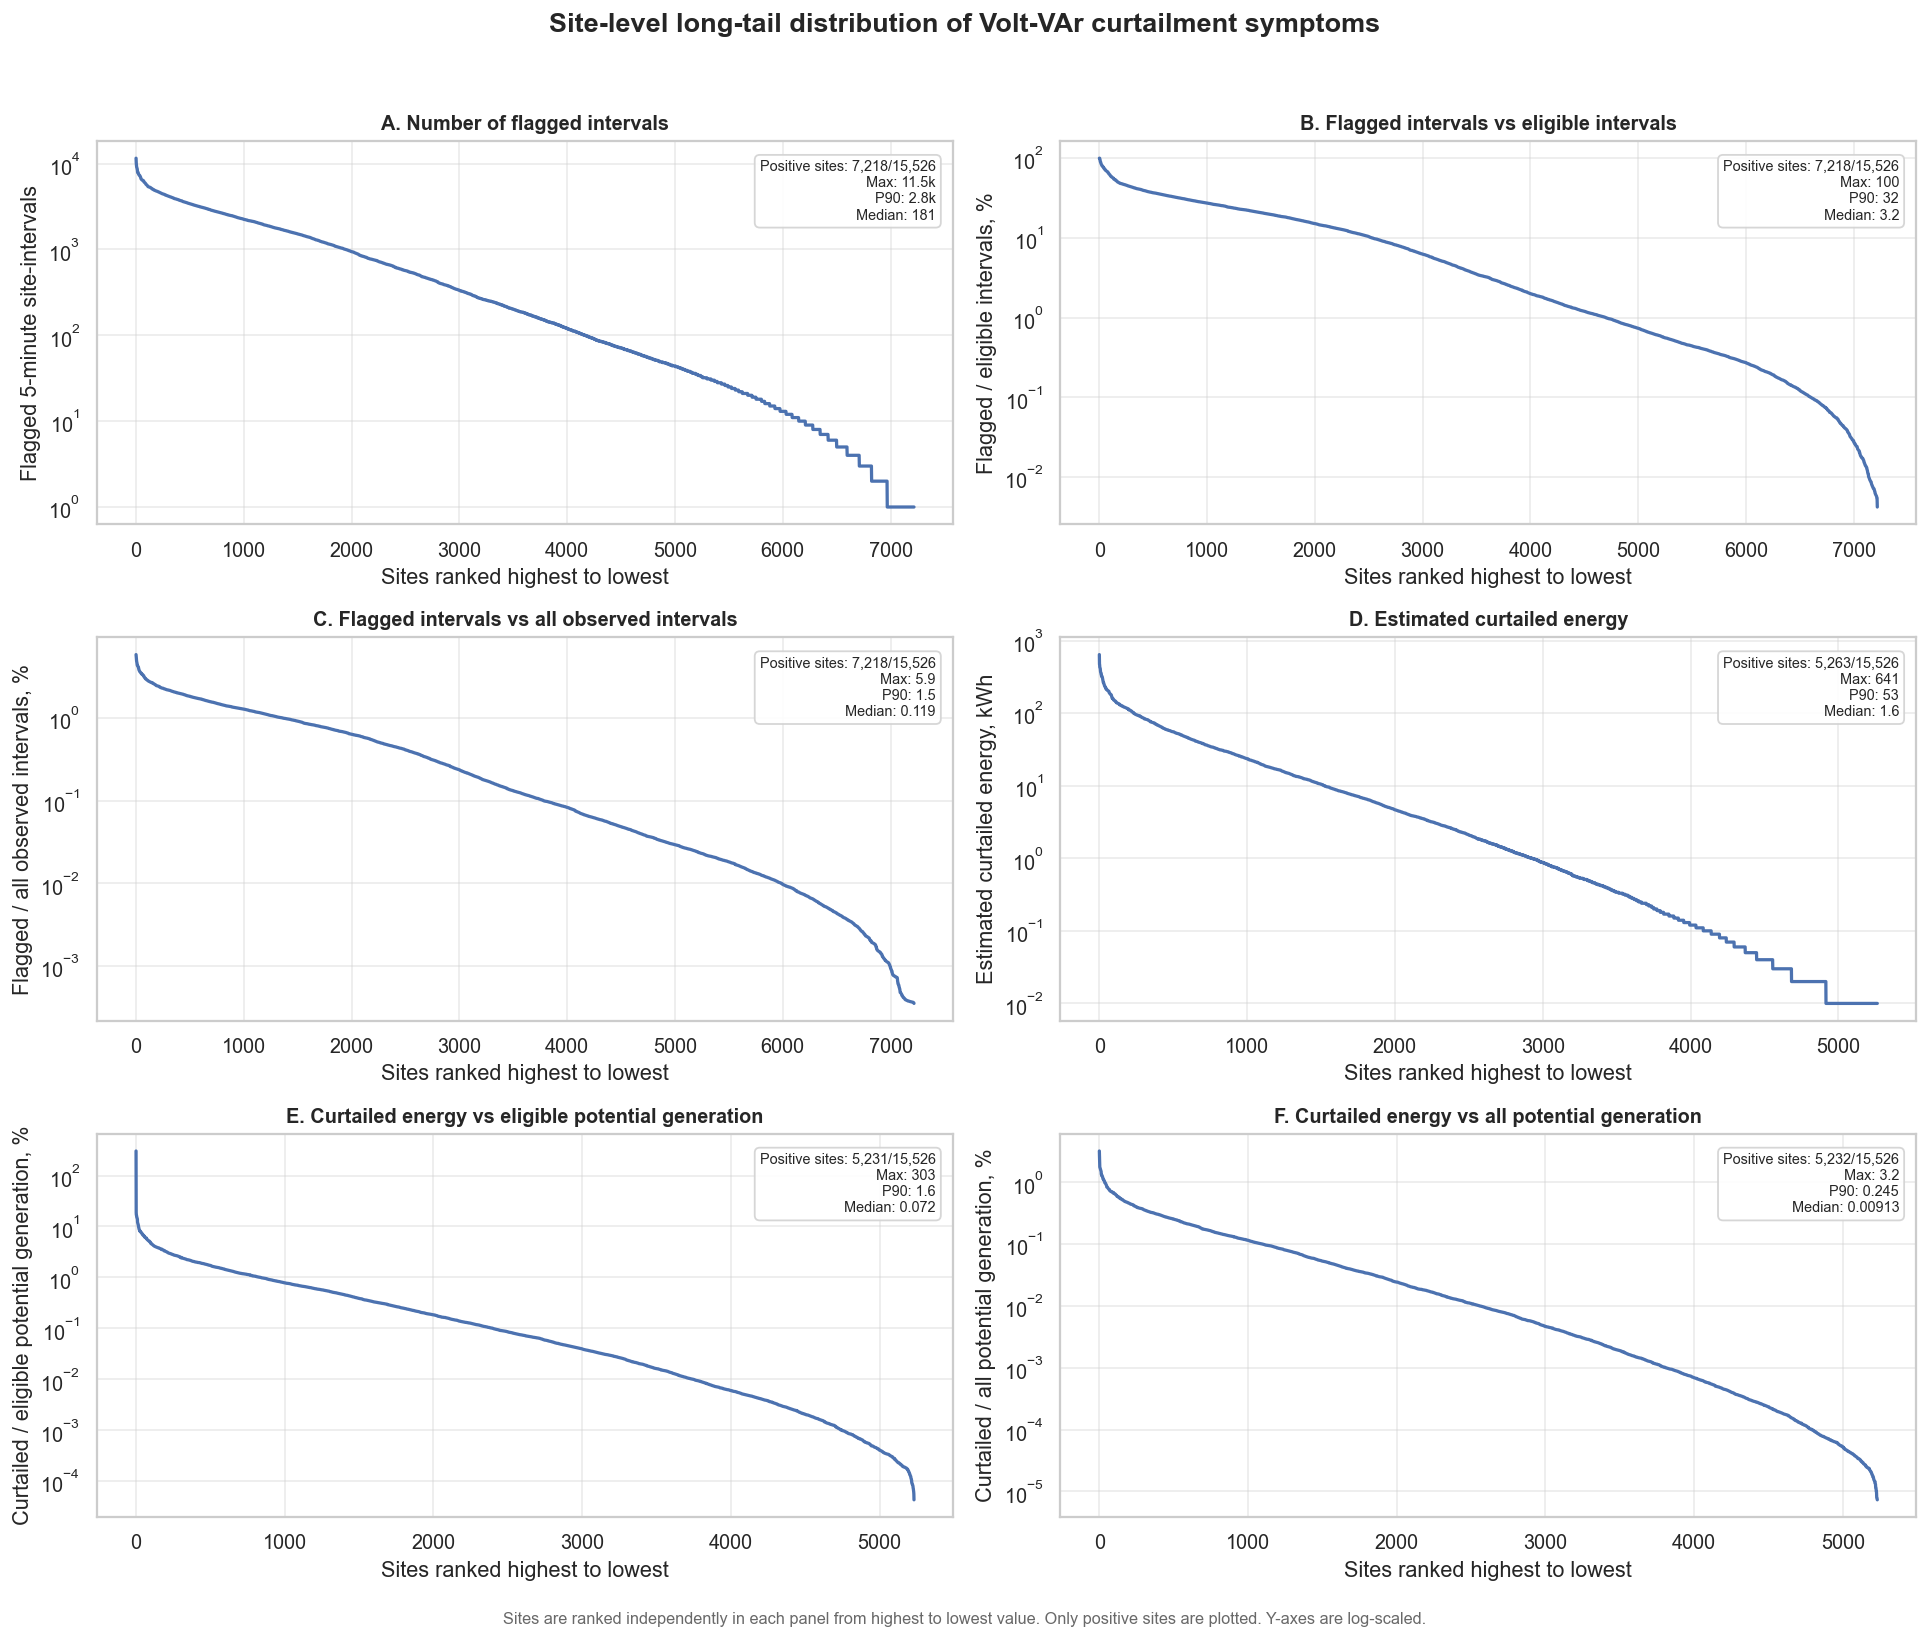

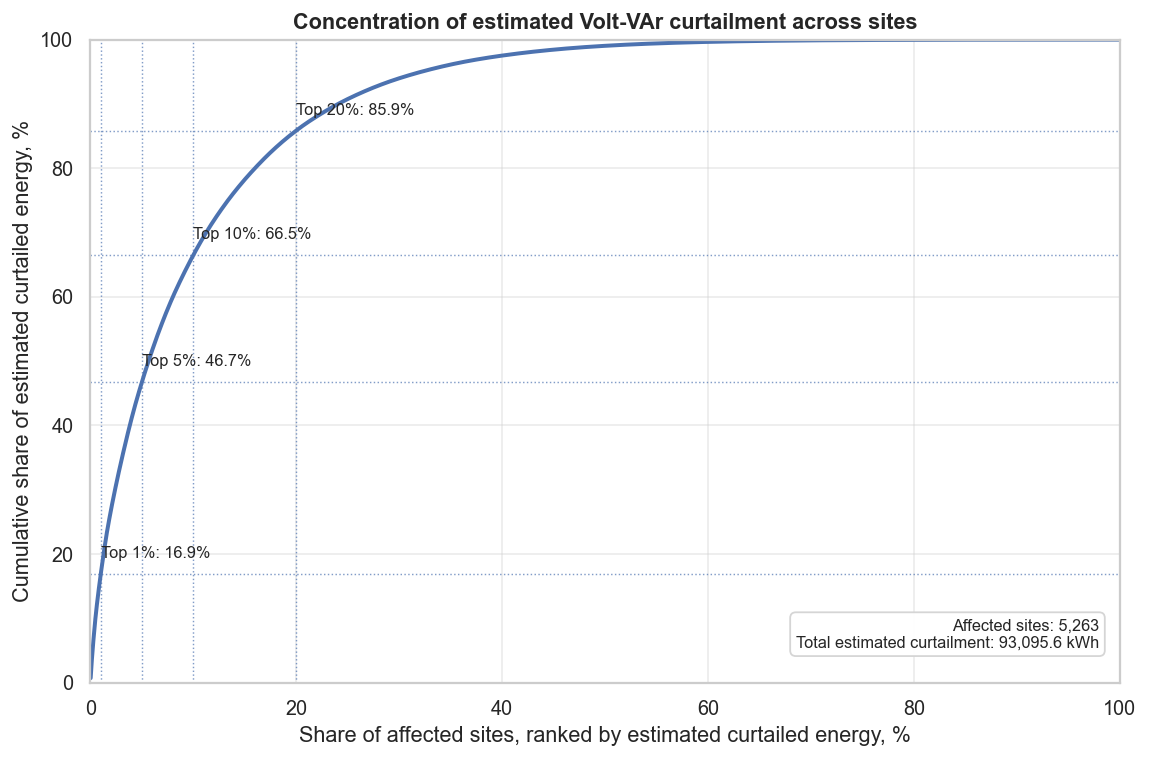


Top 25 sites by estimated curtailed energy:


,site_id,flagged_intervals,flagged_hours,pct_eligible_timestamps_flagged,pct_all_timestamps_flagged,est_curtailed_kWh,pct_eligible_potential_curtailed,pct_all_potential_curtailed,avg_est_curtailed_kW_when_flagged,eligible_intervals,all_intervals,eligible_potential_kWh,all_potential_kWh
15245,2105830595,8857,738.083333,50.158568,4.232999,641.19,6.285458,1.357015,0.868723,17658,209237,10201.166,47250.027
3688,508858566,5898,491.5,44.780199,2.137754,471.30,6.835030,0.705373,0.958901,13171,275897,6895.361,66815.736
11514,1598634062,4082,340.166667,27.361083,1.527100,464.14,5.754725,0.835072,1.364449,14919,267304,8065.372,55580.828
6446,895507958,7885,657.083333,32.494025,2.876278,429.08,3.776608,0.816334,0.653007,24266,274139,11361.517,52561.806
10747,1493831319,4802,400.166667,38.111111,2.975641,422.30,5.758353,1.078100,1.055310,12600,161377,7333.694,39170.776
13789,1904096858,3920,326.666667,27.764006,1.595136,418.41,6.992883,1.127719,1.280847,14119,245747,5983.369,37102.312
2320,321828897,5450,454.166667,31.089561,2.076040,412.49,4.511286,0.802980,0.908235,17530,262519,9143.513,51369.890
8606,1197777914,3163,263.583333,27.619630,1.584709,383.11,6.769734,1.105920,1.453468,11452,199595,5659.159,34641.758
13155,1819352492,4752,396.0,40.135135,2.946502,372.89,1.731772,0.312103,0.941641,11840,161276,21532.282,119476.770
3602,497649279,8310,692.5,42.788734,3.042607,362.82,4.048077,0.711272,0.523928,19421,273121,8962.774,51010.010



Concentration of estimated Volt-VAr curtailment:
  Top  1% of affected sites account for  16.9% of estimated curtailment
  Top  5% of affected sites account for  46.7% of estimated curtailment
  Top 10% of affected sites account for  66.5% of estimated curtailment
  Top 20% of affected sites account for  85.9% of estimated curtailment
  Top 50% of affected sites account for  99.0% of estimated curtailment

Total affected sites: 5,263
Total estimated curtailment: 93,095.6 kWh


In [15]:
# =============================================================================
# SITE-LEVEL LONG-TAIL DISTRIBUTION OF VOLT-VAR CURTAILMENT
#
# Purpose:
#   Shows how Volt-VAr curtailment symptoms and estimated energy impact are
#   distributed across individual sites, aggregated across all analysed years.
#
# Requires:
#   candidates
#   eligible_context_by_site_year
#   all_context_by_site_year
#   AS4777["INTERVAL_H"]
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")


# -----------------------------------------------------------------------------
# 1. Build site-level denominator tables
# -----------------------------------------------------------------------------

# Eligible denominator:
# same operating window used for the Volt-VAr screen:
# high-voltage, clear-sky, peak-solar, etc.
eligible_site = (
    eligible_context_by_site_year
    .groupby("site_id", as_index=False)
    .agg(
        eligible_intervals=("n_eligible_intervals", "sum"),
        eligible_potential_kWh=("eligible_potential_kWh", "sum")
    )
)

# All-timestamp denominator:
# all observed PV timestamps for comparable sites
all_site = (
    all_context_by_site_year
    .groupby("site_id", as_index=False)
    .agg(
        all_intervals=("n_all_intervals", "sum"),
        all_potential_kWh=("all_potential_kWh", "sum")
    )
)

# Numerator:
# affected / flagged sites from Method A
candidate_site = (
    candidates
    .groupby("site_id", as_index=False)
    .agg(
        flagged_intervals=("n_flagged_intervals", "sum"),
        est_curtailed_kWh=("est_curtailed_kWh", "sum")
    )
)

# Merge onto the full comparable site universe
site_dist = (
    all_site
    .merge(eligible_site, on="site_id", how="left")
    .merge(candidate_site, on="site_id", how="left")
)

# Replace missing numerator values with zero
site_dist["flagged_intervals"] = site_dist["flagged_intervals"].fillna(0)
site_dist["est_curtailed_kWh"] = site_dist["est_curtailed_kWh"].fillna(0)

# Replace missing eligible denominators with zero
site_dist["eligible_intervals"] = site_dist["eligible_intervals"].fillna(0)
site_dist["eligible_potential_kWh"] = site_dist["eligible_potential_kWh"].fillna(0)


# -----------------------------------------------------------------------------
# 2. Calculate site-level metrics
# -----------------------------------------------------------------------------

site_dist["flagged_hours"] = (
    site_dist["flagged_intervals"] * AS4777["INTERVAL_H"]
)

site_dist["pct_eligible_timestamps_flagged"] = np.where(
    site_dist["eligible_intervals"] > 0,
    site_dist["flagged_intervals"] / site_dist["eligible_intervals"] * 100,
    np.nan
)

site_dist["pct_all_timestamps_flagged"] = np.where(
    site_dist["all_intervals"] > 0,
    site_dist["flagged_intervals"] / site_dist["all_intervals"] * 100,
    np.nan
)

site_dist["pct_eligible_potential_curtailed"] = np.where(
    site_dist["eligible_potential_kWh"] > 0,
    site_dist["est_curtailed_kWh"] / site_dist["eligible_potential_kWh"] * 100,
    np.nan
)

site_dist["pct_all_potential_curtailed"] = np.where(
    site_dist["all_potential_kWh"] > 0,
    site_dist["est_curtailed_kWh"] / site_dist["all_potential_kWh"] * 100,
    np.nan
)

site_dist["avg_est_curtailed_kW_when_flagged"] = np.where(
    site_dist["flagged_intervals"] > 0,
    site_dist["est_curtailed_kWh"] /
    (site_dist["flagged_intervals"] * AS4777["INTERVAL_H"]),
    np.nan
)

site_dist["affected"] = site_dist["flagged_intervals"] > 0


# -----------------------------------------------------------------------------
# 3. Helper functions
# -----------------------------------------------------------------------------

def _fmt_num(x, decimals=1):
    if pd.isna(x):
        return "n/a"
    if abs(x) >= 1_000_000:
        return f"{x/1_000_000:.{decimals}f}M"
    if abs(x) >= 1_000:
        return f"{x/1_000:.{decimals}f}k"
    if abs(x) >= 10:
        return f"{x:,.0f}"
    if abs(x) >= 1:
        return f"{x:,.1f}"
    if abs(x) >= 0.01:
        return f"{x:,.3f}"
    return f"{x:,.5f}"


def _fmt_pct(x, decimals=3):
    if pd.isna(x):
        return "n/a"
    if abs(x) >= 10:
        return f"{x:.1f}%"
    if abs(x) >= 1:
        return f"{x:.2f}%"
    return f"{x:.{decimals}f}%"


def make_ranked_df(df, metric_col, positive_only=True):
    """
    Sort sites from highest to lowest metric value.
    Uses site rank rather than site_id on x-axis.
    """
    d = df.copy()

    if positive_only:
        d = d[d[metric_col].fillna(0) > 0].copy()
    else:
        d = d[d[metric_col].notna()].copy()

    d = d.sort_values(metric_col, ascending=False).reset_index(drop=True)
    d["site_rank"] = np.arange(1, len(d) + 1)
    d["site_rank_pct"] = d["site_rank"] / len(d) * 100 if len(d) else np.nan

    return d


def plot_ranked_metric(
    ax,
    df,
    metric_col,
    title,
    ylabel,
    positive_only=True,
    log_y=True
):
    d = make_ranked_df(df, metric_col, positive_only=positive_only)

    if d.empty:
        ax.text(0.5, 0.5, "No positive values", ha="center", va="center")
        ax.set_title(title, weight="bold")
        ax.set_xlabel("Site rank")
        ax.set_ylabel(ylabel)
        return

    ax.plot(d["site_rank"], d[metric_col], lw=1.8)

    ax.set_title(title, weight="bold", fontsize=11)
    ax.set_xlabel("Sites ranked highest to lowest")
    ax.set_ylabel(ylabel)

    if log_y:
        ax.set_yscale("log")

    ax.grid(True, which="major", alpha=0.35)

    # Summary annotation
    n_positive = len(d)
    n_total = len(df)
    max_val = d[metric_col].max()
    median_val = d[metric_col].median()
    p90_val = d[metric_col].quantile(0.90)

    txt = (
        f"Positive sites: {n_positive:,}/{n_total:,}\n"
        f"Max: {_fmt_num(max_val)}\n"
        f"P90: {_fmt_num(p90_val)}\n"
        f"Median: {_fmt_num(median_val)}"
    )

    ax.text(
        0.98,
        0.95,
        txt,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgrey",
            alpha=0.92
        )
    )


# -----------------------------------------------------------------------------
# 4. Figure A: ranked long-tail distributions by site
# -----------------------------------------------------------------------------

fig, axes = plt.subplots(3, 2, figsize=(15, 12), dpi=130)
axes = axes.flatten()

plot_ranked_metric(
    ax=axes[0],
    df=site_dist,
    metric_col="flagged_intervals",
    title="A. Number of flagged intervals",
    ylabel="Flagged 5-minute site-intervals",
    positive_only=True,
    log_y=True
)

plot_ranked_metric(
    ax=axes[1],
    df=site_dist,
    metric_col="pct_eligible_timestamps_flagged",
    title="B. Flagged intervals vs eligible intervals",
    ylabel="Flagged / eligible intervals, %",
    positive_only=True,
    log_y=True
)

plot_ranked_metric(
    ax=axes[2],
    df=site_dist,
    metric_col="pct_all_timestamps_flagged",
    title="C. Flagged intervals vs all observed intervals",
    ylabel="Flagged / all observed intervals, %",
    positive_only=True,
    log_y=True
)

plot_ranked_metric(
    ax=axes[3],
    df=site_dist,
    metric_col="est_curtailed_kWh",
    title="D. Estimated curtailed energy",
    ylabel="Estimated curtailed energy, kWh",
    positive_only=True,
    log_y=True
)

plot_ranked_metric(
    ax=axes[4],
    df=site_dist,
    metric_col="pct_eligible_potential_curtailed",
    title="E. Curtailed energy vs eligible potential generation",
    ylabel="Curtailed / eligible potential generation, %",
    positive_only=True,
    log_y=True
)

plot_ranked_metric(
    ax=axes[5],
    df=site_dist,
    metric_col="pct_all_potential_curtailed",
    title="F. Curtailed energy vs all potential generation",
    ylabel="Curtailed / all potential generation, %",
    positive_only=True,
    log_y=True
)

fig.suptitle(
    "Site-level long-tail distribution of Volt-VAr curtailment symptoms",
    fontsize=15,
    weight="bold",
    y=1.02
)

fig.text(
    0.5,
    -0.005,
    "Sites are ranked independently in each panel from highest to lowest value. "
    "Only positive sites are plotted. Y-axes are log-scaled.",
    ha="center",
    va="top",
    fontsize=9,
    color="dimgray"
)

plt.tight_layout()
plt.show()


# -----------------------------------------------------------------------------
# 5. Figure B: cumulative contribution of sites to total estimated curtailment
# -----------------------------------------------------------------------------

curt_rank = make_ranked_df(
    site_dist,
    metric_col="est_curtailed_kWh",
    positive_only=True
)

if curt_rank.empty:
    print("No sites with positive estimated curtailment.")
else:
    total_curt_kWh = curt_rank["est_curtailed_kWh"].sum()

    curt_rank["cum_curtailed_kWh"] = curt_rank["est_curtailed_kWh"].cumsum()
    curt_rank["cum_share_curtailed_pct"] = (
        curt_rank["cum_curtailed_kWh"] / total_curt_kWh * 100
    )
    curt_rank["share_of_affected_sites_pct"] = (
        curt_rank["site_rank"] / len(curt_rank) * 100
    )

    fig, ax = plt.subplots(figsize=(9, 6), dpi=130)

    ax.plot(
        curt_rank["share_of_affected_sites_pct"],
        curt_rank["cum_share_curtailed_pct"],
        lw=2.2
    )

    ax.set_xlabel("Share of affected sites, ranked by estimated curtailed energy, %")
    ax.set_ylabel("Cumulative share of estimated curtailed energy, %")
    ax.set_title(
        "Concentration of estimated Volt-VAr curtailment across sites",
        weight="bold"
    )

    ax.set_xlim(0, 100)
    ax.set_ylim(0, 100)
    ax.grid(True, alpha=0.35)

    # Reference lines
    for x in [1, 5, 10, 20]:
        if x <= 100:
            y = np.interp(
                x,
                curt_rank["share_of_affected_sites_pct"],
                curt_rank["cum_share_curtailed_pct"]
            )
            ax.axvline(x, lw=0.8, ls=":", alpha=0.7)
            ax.axhline(y, lw=0.8, ls=":", alpha=0.7)
            ax.text(
                x,
                y + 2,
                f"Top {x}%: {y:.1f}%",
                ha="left",
                va="bottom",
                fontsize=9
            )

    ax.text(
        0.98,
        0.05,
        f"Affected sites: {len(curt_rank):,}\n"
        f"Total estimated curtailment: {total_curt_kWh:,.1f} kWh",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=9,
        bbox=dict(
            boxstyle="round,pad=0.35",
            facecolor="white",
            edgecolor="lightgrey",
            alpha=0.95
        )
    )

    plt.tight_layout()
    plt.show()


# -----------------------------------------------------------------------------
# 6. Optional: print top sites table
# -----------------------------------------------------------------------------

top_n = 25

top_sites = (
    site_dist
    .sort_values("est_curtailed_kWh", ascending=False)
    .head(top_n)
    [[
        "site_id",
        "flagged_intervals",
        "flagged_hours",
        "pct_eligible_timestamps_flagged",
        "pct_all_timestamps_flagged",
        "est_curtailed_kWh",
        "pct_eligible_potential_curtailed",
        "pct_all_potential_curtailed",
        "avg_est_curtailed_kW_when_flagged",
        "eligible_intervals",
        "all_intervals",
        "eligible_potential_kWh",
        "all_potential_kWh"
    ]]
    .copy()
)

print(f"\nTop {top_n} sites by estimated curtailed energy:")
display(top_sites)


# -----------------------------------------------------------------------------
# 7. Optional: summary of concentration
# -----------------------------------------------------------------------------

if not curt_rank.empty:
    print("\nConcentration of estimated Volt-VAr curtailment:")

    for pct_sites in [1, 5, 10, 20, 50]:
        y = np.interp(
            pct_sites,
            curt_rank["share_of_affected_sites_pct"],
            curt_rank["cum_share_curtailed_pct"]
        )
        print(f"  Top {pct_sites:>2}% of affected sites account for {y:5.1f}% of estimated curtailment")

    print(f"\nTotal affected sites: {len(curt_rank):,}")
    print(f"Total estimated curtailment: {total_curt_kWh:,.1f} kWh")

In [16]:
top_sites

,site_id,flagged_intervals,flagged_hours,pct_eligible_timestamps_flagged,pct_all_timestamps_flagged,est_curtailed_kWh,pct_eligible_potential_curtailed,pct_all_potential_curtailed,avg_est_curtailed_kW_when_flagged,eligible_intervals,all_intervals,eligible_potential_kWh,all_potential_kWh
15245,2105830595,8857,738.083333,50.158568,4.232999,641.19,6.285458,1.357015,0.868723,17658,209237,10201.166,47250.027
3688,508858566,5898,491.5,44.780199,2.137754,471.30,6.835030,0.705373,0.958901,13171,275897,6895.361,66815.736
11514,1598634062,4082,340.166667,27.361083,1.527100,464.14,5.754725,0.835072,1.364449,14919,267304,8065.372,55580.828
6446,895507958,7885,657.083333,32.494025,2.876278,429.08,3.776608,0.816334,0.653007,24266,274139,11361.517,52561.806
10747,1493831319,4802,400.166667,38.111111,2.975641,422.30,5.758353,1.078100,1.055310,12600,161377,7333.694,39170.776
13789,1904096858,3920,326.666667,27.764006,1.595136,418.41,6.992883,1.127719,1.280847,14119,245747,5983.369,37102.312
2320,321828897,5450,454.166667,31.089561,2.076040,412.49,4.511286,0.802980,0.908235,17530,262519,9143.513,51369.890
8606,1197777914,3163,263.583333,27.619630,1.584709,383.11,6.769734,1.105920,1.453468,11452,199595,5659.159,34641.758
13155,1819352492,4752,396.0,40.135135,2.946502,372.89,1.731772,0.312103,0.941641,11840,161276,21532.282,119476.770
3602,497649279,8310,692.5,42.788734,3.042607,362.82,4.048077,0.711272,0.523928,19421,273121,8962.774,51010.010


In [17]:
top_sites[['pct_eligible_timestamps_flagged', 'est_curtailed_kWh','pct_eligible_potential_curtailed','pct_all_potential_curtailed']]

,pct_eligible_timestamps_flagged,est_curtailed_kWh,pct_eligible_potential_curtailed,pct_all_potential_curtailed
15245,50.158568,641.19,6.285458,1.357015
3688,44.780199,471.30,6.835030,0.705373
11514,27.361083,464.14,5.754725,0.835072
6446,32.494025,429.08,3.776608,0.816334
10747,38.111111,422.30,5.758353,1.078100
13789,27.764006,418.41,6.992883,1.127719
2320,31.089561,412.49,4.511286,0.802980
8606,27.619630,383.11,6.769734,1.105920
13155,40.135135,372.89,1.731772,0.312103
3602,42.788734,362.82,4.048077,0.711272


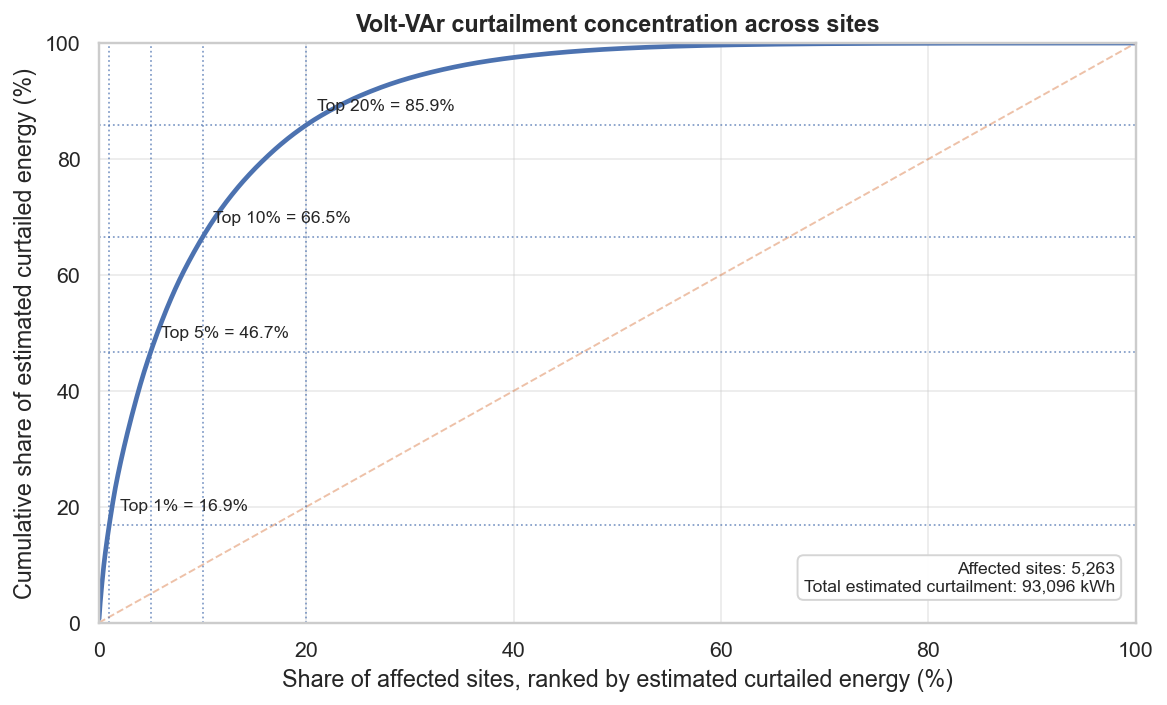

In [18]:
# =============================================================================
# BEST SLIDE PLOT — CUMULATIVE CONTRIBUTION OF AFFECTED SITES
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", context="notebook")

# Use site_dist from previous block
# Required columns:
#   site_id
#   est_curtailed_kWh

curt_rank = (
    site_dist[site_dist["est_curtailed_kWh"].fillna(0) > 0]
    .sort_values("est_curtailed_kWh", ascending=False)
    .reset_index(drop=True)
)

curt_rank["site_rank"] = np.arange(1, len(curt_rank) + 1)
curt_rank["share_of_affected_sites_pct"] = (
    curt_rank["site_rank"] / len(curt_rank) * 100
)

total_curt_kWh = curt_rank["est_curtailed_kWh"].sum()

curt_rank["cum_curtailed_kWh"] = curt_rank["est_curtailed_kWh"].cumsum()
curt_rank["cum_share_curtailed_pct"] = (
    curt_rank["cum_curtailed_kWh"] / total_curt_kWh * 100
)

fig, ax = plt.subplots(figsize=(8.5, 5.2), dpi=140)

ax.plot(
    curt_rank["share_of_affected_sites_pct"],
    curt_rank["cum_share_curtailed_pct"],
    lw=2.4
)

ax.plot([0, 100], [0, 100], ls="--", lw=1, alpha=0.5)

ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

ax.set_xlabel("Share of affected sites, ranked by estimated curtailed energy (%)")
ax.set_ylabel("Cumulative share of estimated curtailed energy (%)")
ax.set_title(
    "Volt-VAr curtailment concentration across sites",
    weight="bold"
)

ax.grid(True, alpha=0.35)

# Annotate useful thresholds
for x in [1, 5, 10, 20]:
    y = np.interp(
        x,
        curt_rank["share_of_affected_sites_pct"],
        curt_rank["cum_share_curtailed_pct"]
    )

    ax.axvline(x, ls=":", lw=0.9, alpha=0.7)
    ax.axhline(y, ls=":", lw=0.9, alpha=0.7)

    ax.text(
        x + 1,
        y + 2,
        f"Top {x}% = {y:.1f}%",
        fontsize=9,
        va="bottom"
    )

ax.text(
    0.98,
    0.05,
    f"Affected sites: {len(curt_rank):,}\n"
    f"Total estimated curtailment: {total_curt_kWh:,.0f} kWh",
    transform=ax.transAxes,
    ha="right",
    va="bottom",
    fontsize=9,
    bbox=dict(
        boxstyle="round,pad=0.35",
        facecolor="white",
        edgecolor="lightgrey",
        alpha=0.95
    )
)

plt.tight_layout()
plt.show()

## 8 · Notes, caveats, and next steps

**What changed from the previous version**: replaced the arbitrary `S_LIMIT_FRAC=0.97` with
`S_TOL_FRAC` tied to the established 4% AC-capacity tolerance convention; clarified that
`GHI_CS_RATIO_MIN=0.85` has no precedent elsewhere and is tunable; added multi-year support
(`PARAMS["YEARS"]` vs `PARAMS["GHI_YEARS"]`); added a `PHASE_FILTER` toggle (default: include
both single- and three-phase, matching the established cohort convention); fixed `ghi`/`ghi_cs`
casing; added fleet-wide compliance-by-voltage visualisations, a full-day 3-power-line plot with
curtailment shading, an improved apparent-power-circle plot with on-limit highlighting, and
fleet-context denominators in the summary section.

**Caveats to keep in mind**

1. **`S_99` vs nameplate** — `S_99` is the empirical limit and usually the right choice, but for
   sites that have been curtailing for most of their history, `S_99` is itself depressed, which
   *under*-counts curtailment. Toggle `USE_S99` to compare.
2. **GHI/`all_uncurtailedpv` coverage is `PARAMS["GHI_YEARS"]` only** (currently `[2024]`) — Method
   B and the fleet-context denominator can't run for years outside this list.
3. **`GHI_CS_RATIO_MIN` and `S_TOL_FRAC` are tunable, not derived from the standard** — run a
   sensitivity sweep before quoting a headline number.
4. **The 240–253 V band deliberately excludes the 253–258 V overlap zone** where V-VAr and
   V-Watt act together — in the overlap you can't cleanly attribute curtailment to VAr alone.
5. **Three-phase sites use `max(V)` for eligibility but sum P/Q across phases** — see the phase
   discussion above; set `PHASE_FILTER="single"` if this ambiguity matters for your analysis.
6. **`ghi_cs` is an empirical nearest-clear-sky-day reference, not a physical clear-sky model** —
   it inherits whatever shading/soiling/noise was present on that specific reference day.

**Suggested next steps**

- Run Method A with `USE_S99=True` and `False`; report the range.
- Sensitivity-check `GHI_CS_RATIO_MIN` at 0.80 / 0.85 / 0.90 and confirm the candidate site list
  is stable.
- Cross-tabulate affected sites by **DNSP** and **OEM** — some inverter brands default to
  fixed-PF and won't show this symptom at all, which is itself a finding worth reporting.
- Compare the Volt-VAr-curtailment site list against the Volt-Watt-curtailment list: sites doing
  *both* are losing the most generation at high voltage.


In [19]:
# ── Fleet funnel diagnostic: trace exactly how many sites survive each filter ─
_ctx_year   = PARAMS["GHI_YEARS"][0]
_limit_col  = "s_99" if PARAMS["USE_S99"] else "ac_capacity_kw"

print("Running funnel diagnostic — 4 separate Athena queries...")

# Step 0: every site with at least one PV circuit
step0 = aq(f"""
    SELECT count(DISTINCT site_id) AS n
    FROM meta_up23c
    WHERE is_pv = True
      AND ac_capacity_kw > 0
      AND ac_capacity_kw <= {PARAMS['MAX_AC_CAPACITY_KW']}
""", database=SAI)

# Step 1: + valid apparent-power limit (s_99 or ac_capacity_kw > 0)
step1 = aq(f"""
    SELECT count(DISTINCT site_id) AS n
    FROM meta_up23c
    WHERE is_pv = True
      AND {_limit_col} > 0
      AND ac_capacity_kw > 0
      AND ac_capacity_kw <= {PARAMS['MAX_AC_CAPACITY_KW']}
""", database=SAI)

# Step 2: + at least one 5-min interval in the 240-253V band, this year
step2 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
            WHERE is_pv = True
            AND {_limit_col} > 0
            AND ac_capacity_kw > 0
            AND ac_capacity_kw <= {PARAMS['MAX_AC_CAPACITY_KW']}) sm
      ON t.circuit_id = sm.circuit_id
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
""", database=SAI)

# Step 3: + also within the peak-solar window (11:00-13:00 AEST)
step3 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
          WHERE is_pv = True
            AND {_limit_col} > 0
            AND ac_capacity_kw > 0
            AND ac_capacity_kw <= {PARAMS['MAX_AC_CAPACITY_KW']}) sm
      ON t.circuit_id = sm.circuit_id
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
      AND hour(t.t_stamp + interval '10' hour)
          BETWEEN {PARAMS['PEAK_HOUR_START']} AND {PARAMS['PEAK_HOUR_END']}
""", database=SAI)

# Step 4: + also clear-sky (ghi/ghi_cs >= GHI_CS_RATIO_MIN) — this is n_eligible_sites
step4 = aq(f"""
    SELECT count(DISTINCT sm.site_id) AS n
    FROM ts t
    JOIN (SELECT DISTINCT site_id, circuit_id FROM meta_up23c
          WHERE is_pv = True AND {_limit_col} > 0) sm
      ON t.circuit_id = sm.circuit_id
    JOIN structured_data sd
      ON sm.site_id = sd.site_id AND t.t_stamp = sd.t_stamp
    WHERE t.year = {_ctx_year} AND t.is_pv = True
      AND t.voltage > {PARAMS['V_LOW']} AND t.voltage < {PARAMS['V_HIGH']}
      AND hour(t.t_stamp + interval '10' hour)
          BETWEEN {PARAMS['PEAK_HOUR_START']} AND {PARAMS['PEAK_HOUR_END']}
      AND sd.ghi_cs > 0 AND sd.ghi / sd.ghi_cs >= {PARAMS['GHI_CS_RATIO_MIN']}
""", database=SAI)

funnel = pd.DataFrame({
    "stage": [
        "0. All is_pv sites",
        f"1. + valid {_limit_col}",
        f"2. + any 5-min interval {PARAMS['V_LOW']:.0f}-{PARAMS['V_HIGH']:.0f}V ({_ctx_year})",
        f"3. + within peak-solar window ({PARAMS['PEAK_HOUR_START']}:00-{PARAMS['PEAK_HOUR_END']}:00)",
        f"4. + clear-sky (ghi/ghi_cs >= {PARAMS['GHI_CS_RATIO_MIN']})",
    ],
    "n_sites": [step0["n"].iloc[0], step1["n"].iloc[0], step2["n"].iloc[0],
               step3["n"].iloc[0], step4["n"].iloc[0]],
})
funnel["pct_of_start"] = (funnel["n_sites"] / funnel["n_sites"].iloc[0] * 100).round(1)
funnel["dropped_this_step"] = funnel["n_sites"].diff().fillna(0).astype(int).abs()

print(funnel.to_string(index=False))
print(f"\nFinal n_eligible_sites (step 4) should match the fleet_context query: "
      f"{funnel['n_sites'].iloc[-1]:,}")

Running funnel diagnostic — 4 separate Athena queries...
                                      stage  n_sites  pct_of_start  dropped_this_step
                         0. All is_pv sites    15526         100.0                  0
                            1. + valid s_99    15526         100.0                  0
    2. + any 5-min interval 240-253V (2024)    13986          90.1               1540
3. + within peak-solar window (11:00-13:00)    13912          89.6                 74
        4. + clear-sky (ghi/ghi_cs >= 0.95)    13725          88.4                187

Final n_eligible_sites (step 4) should match the fleet_context query: 13,725
